In [1]:
import time
import numpy as np
from numpy import mean, std, dstack
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, matthews_corrcoef
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling1D, Dropout, InputLayer
from tensorflow.keras.callbacks import History
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Layer
import xlsxwriter
from tensorflow.keras.regularizers import l2
from keras import layers
import keras
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

In [2]:
class Time2Vec(Layer):
    def __init__(self, kernel_size=1):
        super(Time2Vec, self).__init__()
        self.k = kernel_size

    def build(self, input_shape):
        self.w0 = self.add_weight(name="w0", shape=(1,), initializer="uniform", trainable=True)
        self.b0 = self.add_weight(name="b0", shape=(1,), initializer="uniform", trainable=True)
        self.w = self.add_weight(name="w", shape=(input_shape[-1], self.k), initializer="uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.k,), initializer="uniform", trainable=True)

    def call(self, inputs):
        v1 = self.w0 * inputs + self.b0
        v2 = tf.math.sin(tf.matmul(inputs, self.w) + self.b)
        return tf.concat([v1, v2], axis=-1)

In [3]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [4]:
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_classes,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=8, activation='relu', bias_regularizer='l2')(inputs)
    x = layers.MaxPooling1D(pool_size=17,strides=9)(x)
    x = Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)

    x = Time2Vec()(x)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


In [5]:
def evaluate_model(trainX, trainy, testX, testy, sujet):
    verbose, epochs, batch_size = 1, 200, 64
    # Extract dimensions from training data:
    n_timesteps = trainX.shape[1]
    d_model= trainX.shape[2]  # This is 12 in your case
    n_outputs = trainy.shape[1]

    print("Train Data Shape:", trainX.shape)  # (num_samples, sequence_length, 12)
    print("Test Data Shape:", testX.shape)

    # Build the classifier model using the raw input dimension and then projecting internally.
    model = build_model(
       input_shape=(n_timesteps, d_model),
       head_size=64,
       num_heads=4,
       num_classes=n_outputs,
       ff_dim=256,
       num_transformer_blocks=3,
       mlp_units=[256],
       mlp_dropout=0.6,
       dropout=0.5,
    )
    model.summary()

    # Compile the model with categorical crossentropy and Adam optimizer.
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.0001),
                  metrics=['accuracy'])

    # Train the model
    start = time.time()
    model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[history])
    train_time = time.time() - start  # seconds

    # Save the model
    model.save(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\transformer2' + str(sujet) + '_Transformer_model.h5')

    # Evaluate on training data
    loss_train, accuracy_train = model.evaluate(trainX, trainy, batch_size=batch_size, verbose=1)
    start = time.time()
    loss_test, accuracy_test = model.evaluate(testX, testy, batch_size=batch_size, verbose=1)
    test_time = time.time() - start  # seconds

    # Predict on test data and convert predictions to class indices
    y_pred = np.argmax(model.predict(testX), axis=-1)
    testy_indices = [np.argmax(y) for y in testy]

    return loss_train, accuracy_train, loss_test, accuracy_test, y_pred, testy_indices, train_time, test_time


def summarize_results(scores, losses):
    m, s = mean(scores), std(scores)
    mL, sL = mean(losses), std(losses)
    print('\nAccuracy: %.5f (+/-%.5f)' % (m, s))
    print('Loss: %.5f (+/-%.5f)' % (mL, sL))

def run_my_experiment(sujet):
    # Load data from MATLAB file; update the path as needed.
    data = loadmat(fr"D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\data\82_preprocessed_data\S" + str(sujet) + "_E1_A1_300_200_N.mat")

    train_data = data['train_data']      # shape: (num_train_samples, sequence_length, d_model)
    train_labels = data['train_labels']    # shape: (num_train_samples, num_classes)
    test_data = data['test_data']          # shape: (num_test_samples, sequence_length, d_model)
    test_labels = data['test_labels']      # shape: (num_test_samples, num_classes)

    scores = list()
    losses = list()

    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = evaluate_model(
        train_data, train_labels, test_data, test_labels, sujet
    )

    print('>#%d: ' % (sujet))
    print('  train accuracy: %.5f' % (score_train))
    print('  train loss    : %.5f' % (loss_train))
    print('  test accuracy: %.5f' % (score_test))
    print('  test loss    : %.5f' % (loss_test))
    scores.append(score_test)
    losses.append(loss_test)
    summarize_results(scores, losses)

    return loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time


Train Data Shape: (1860, 300, 12)
Test Data Shape: (888, 300, 12)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 293, 64)   │      6,208 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 31, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 31, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 31, 64)    │        256 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec           │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec[0][0],  │
│ (MultiHeadAttentio… │                   │            │ time2_vec[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 31, 65)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 31, 65)    │        130 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 31, 256)   │     16,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 31, 256)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 31, 65)    │     16,705 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 31, 65)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_1[0][0]     

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 209ms/step - accuracy: 0.0713 - loss: 3.3308
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.1021 - loss: 2.7350
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.1272 - loss: 2.6109
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.1517 - loss: 2.5029
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.1702 - loss: 2.4218
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.1833 - loss: 2.4145
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.1997 - loss: 2.3262
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.1841 - loss: 2.2874
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.2060 - loss: 2.2880
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.2203 - loss: 2.2698
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.2272 - loss: 2.1997
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9396 - loss: 0.1702
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8773 - loss: 0.6062
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
>#1: 
  train accuracy: 0.93710
  train loss    : 0.17492
  test accuracy: 0.85360
  test loss    : 0.64709

Accuracy: 0.85360 (+/-0.00000)
Loss: 0.64709 (+/-0.00000)


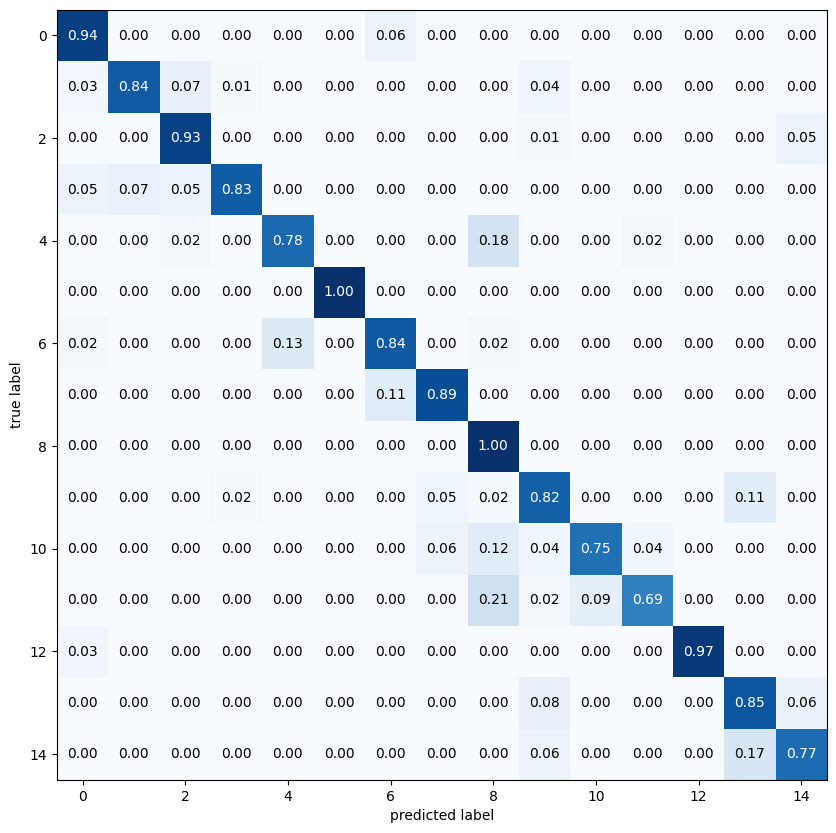

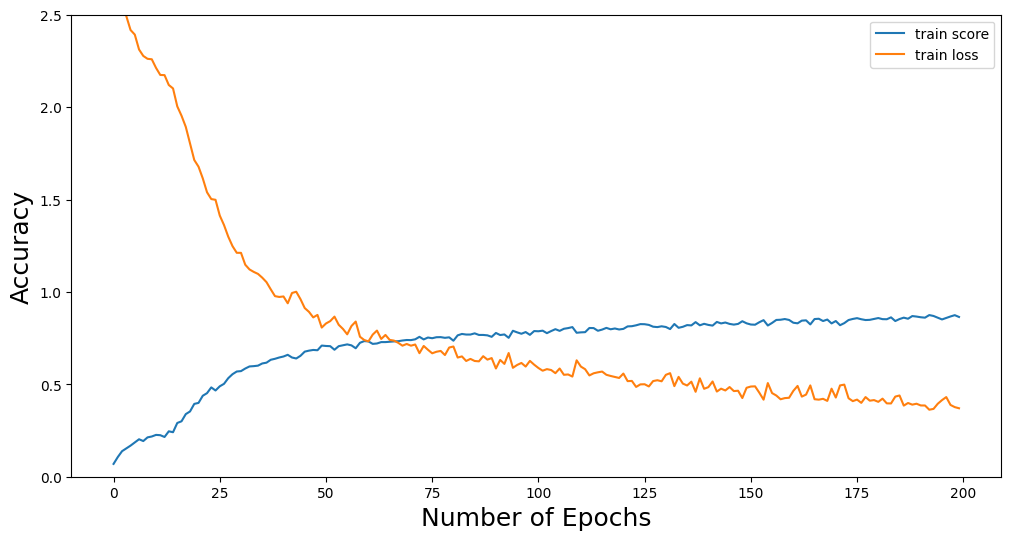

Train Data Shape: (2145, 300, 12)
Test Data Shape: (1068, 300, 12)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 293, 64)   │      6,208 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 31, 64)    │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 31, 64)    │          0 │ max_pooling1d_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_11[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_1         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_13[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 31, 256)   │     16,896 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 31, 256)   │          0 │ conv1d_8[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 31, 65)    │     16,705 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_9[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_7[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_16[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.0810 - loss: 3.0552
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.0934 - loss: 2.7232
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.1144 - loss: 2.6414
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.1238 - loss: 2.6019
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.1377 - loss: 2.5431
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.1755 - loss: 2.4718
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.1515 - loss: 2.4682
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.1811 - loss: 2.4133
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.2056 - loss: 2.3491
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.2325 - loss: 2.2593
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.2359 - loss: 2.2255
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9411 - loss: 0.1712
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8235 - loss: 0.7481
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step
>#2: 
  train accuracy: 0.93706
  train loss    : 0.18421
  test accuracy: 0.82584
  test loss    : 0.70908

Accuracy: 0.82584 (+/-0.00000)
Loss: 0.70908 (+/-0.00000)


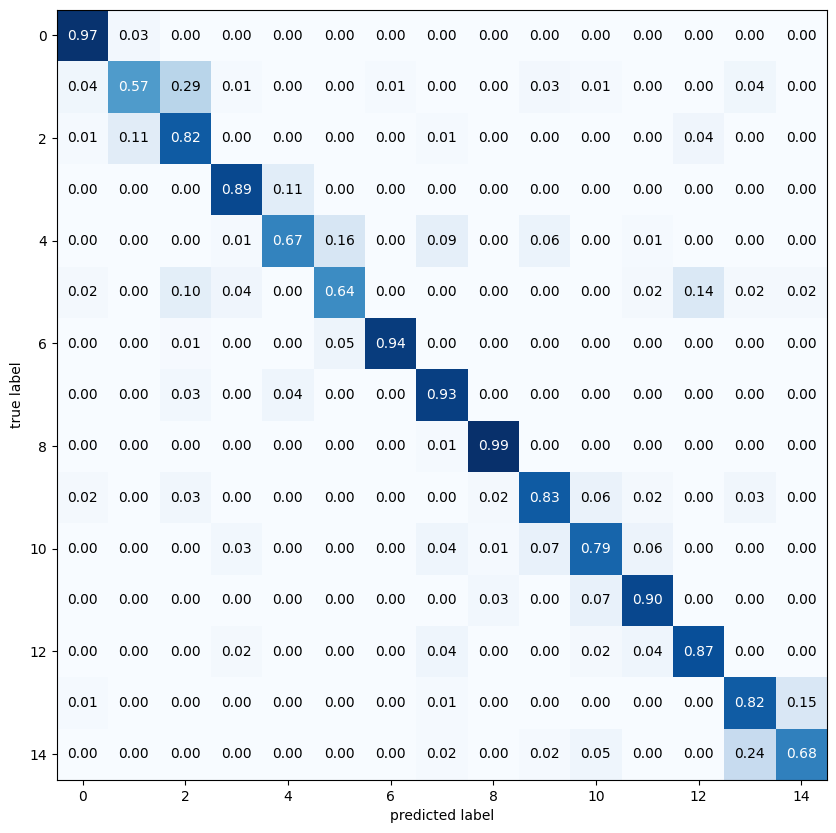

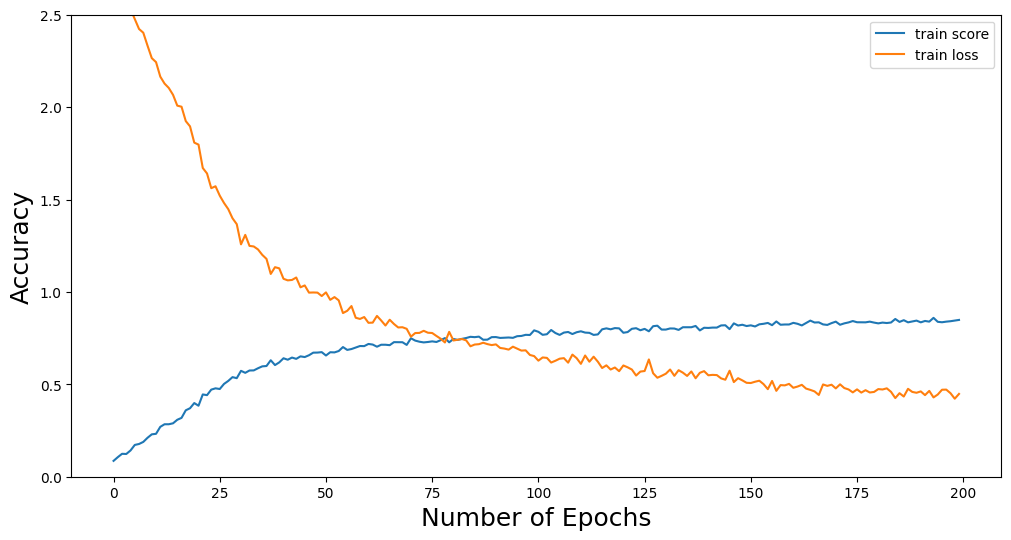

Train Data Shape: (2076, 300, 12)
Test Data Shape: (1015, 300, 12)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 31, 64)    │          0 │ conv1d_14[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 31, 64)    │          0 │ max_pooling1d_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_22[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_2         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_24[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 31, 256)   │          0 │ conv1d_15[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_16[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_13[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_13[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_27[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.0801 - loss: 2.9679
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.1358 - loss: 2.5781
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.1597 - loss: 2.5003
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.1978 - loss: 2.3973
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.2267 - loss: 2.2678
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.2765 - loss: 2.1162
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.2773 - loss: 2.0748
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.3013 - loss: 1.9839
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.3446 - loss: 1.8775
Epoch 10/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.3647 - loss: 1.8397
Epoch 11/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.3759 - loss: 1.7544
Epoch 12/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9338 - loss: 0.1961
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8517 - loss: 0.7152
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
>#3: 
  train accuracy: 0.94171
  train loss    : 0.16965
  test accuracy: 0.83547
  test loss    : 0.91079

Accuracy: 0.83547 (+/-0.00000)
Loss: 0.91079 (+/-0.00000)


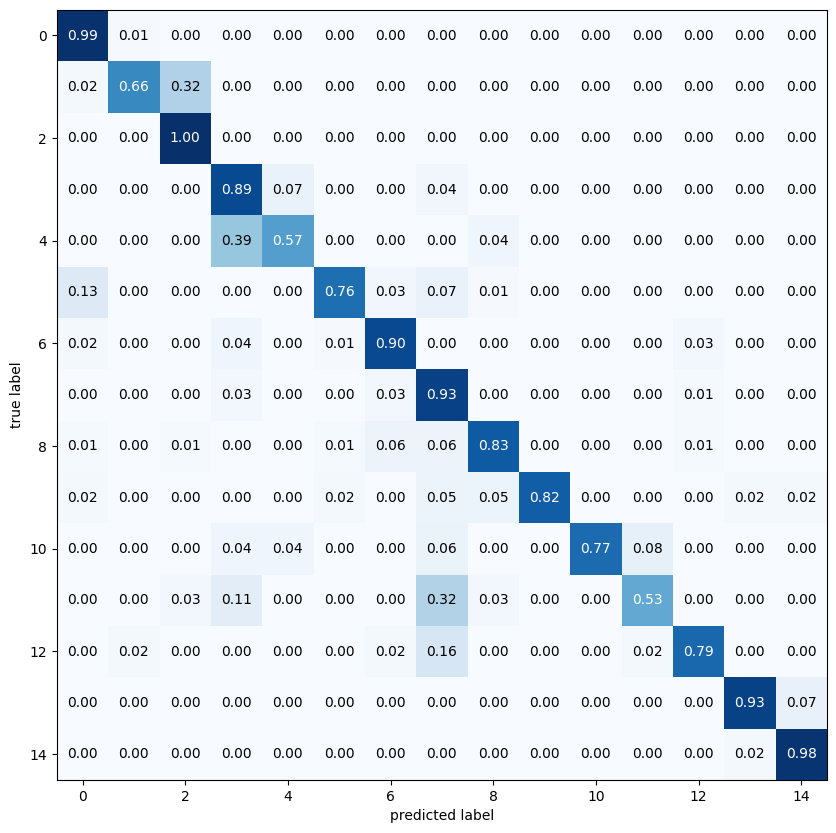

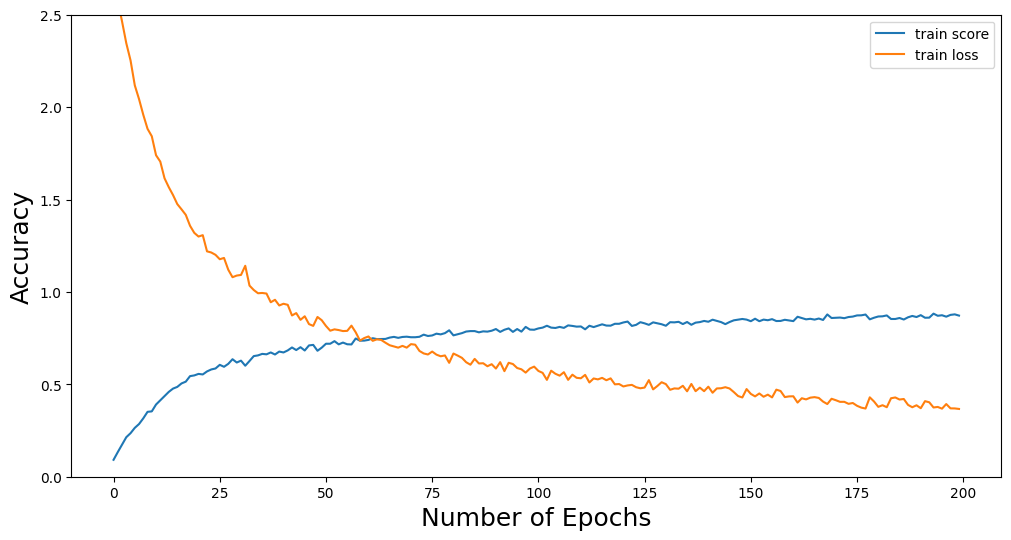

Train Data Shape: (2641, 300, 12)
Test Data Shape: (1227, 300, 12)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 31, 64)    │          0 │ conv1d_21[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 31, 64)    │          0 │ max_pooling1d_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_33[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_3         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_3[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_35[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 31, 256)   │          0 │ conv1d_22[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_23[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_19[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_38[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.0792 - loss: 3.0787
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.0762 - loss: 2.7574
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.0959 - loss: 2.7199
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.1084 - loss: 2.6713
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.1085 - loss: 2.6399
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.1519 - loss: 2.5476
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.1579 - loss: 2.4953
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.1964 - loss: 2.4237
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.2116 - loss: 2.3347
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.2324 - loss: 2.3017
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.2587 - loss: 2.2094
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8992 - loss: 0.2724
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7913 - loss: 0.7466
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
>#4: 
  train accuracy: 0.88944
  train loss    : 0.30664
  test accuracy: 0.77914
  test loss    : 0.80607

Accuracy: 0.77914 (+/-0.00000)
Loss: 0.80607 (+/-0.00000)


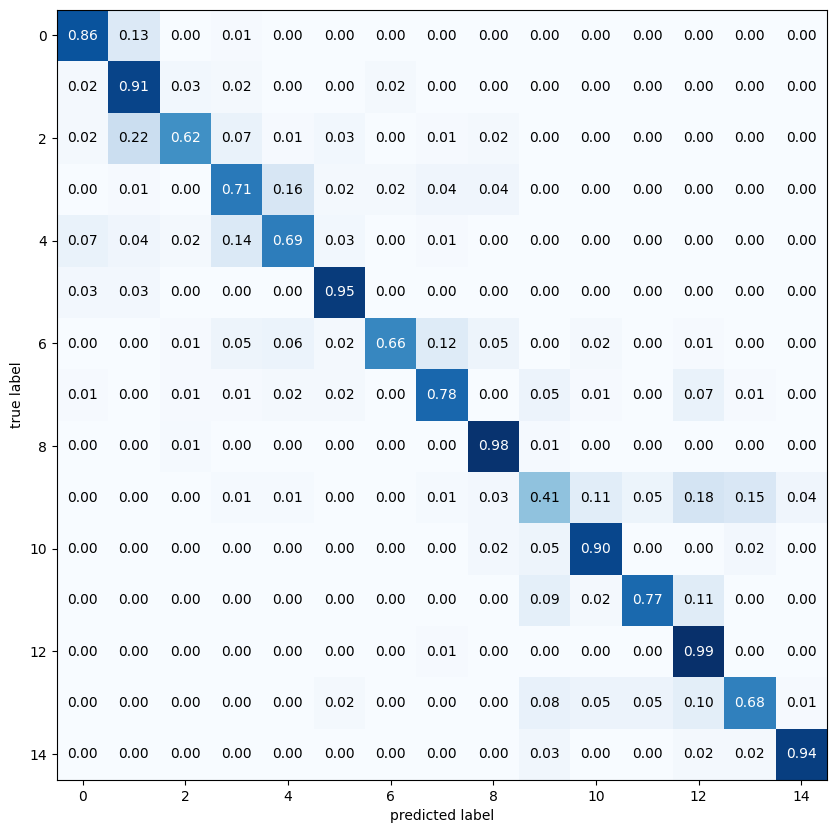

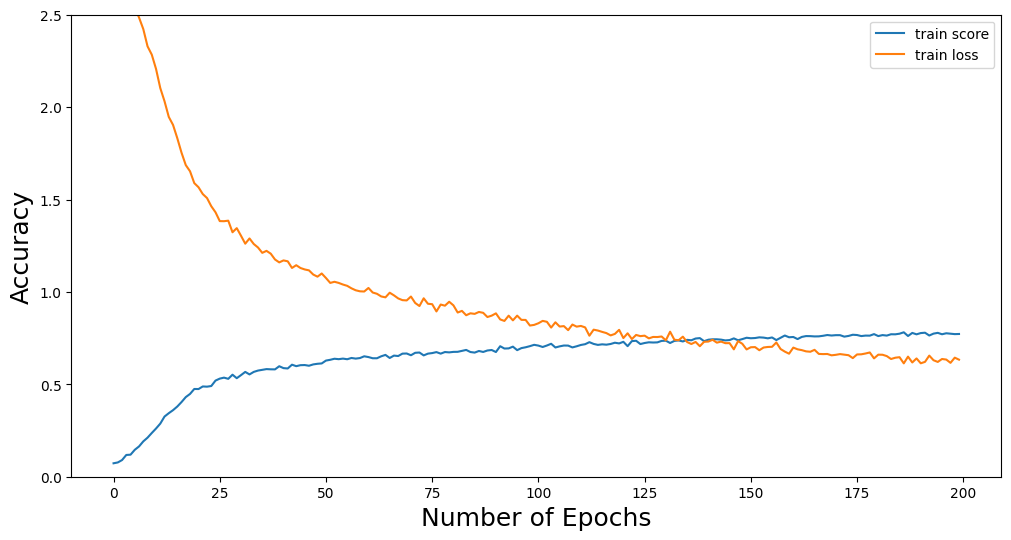

Train Data Shape: (1759, 300, 12)
Test Data Shape: (874, 300, 12)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 31, 64)    │          0 │ conv1d_28[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 31, 64)    │          0 │ max_pooling1d_4[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_44[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_4         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_4[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_46          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_46[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_24[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_47          │ (None, 31, 256)   │          0 │ conv1d_29[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_47[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_30[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_24[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_25[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_25[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_49[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.0739 - loss: 3.0114
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.1240 - loss: 2.6429
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.1539 - loss: 2.4913
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.2027 - loss: 2.3915
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.2153 - loss: 2.2728
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.2477 - loss: 2.1549
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.2774 - loss: 2.0263
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.2802 - loss: 2.0656
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.3368 - loss: 1.9213
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.3394 - loss: 1.8199
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.3859 - loss: 1.7367
Epoch 12/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8631 - loss: 0.3758
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8355 - loss: 0.5059
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
>#5: 
  train accuracy: 0.88175
  train loss    : 0.31966
  test accuracy: 0.84897
  test loss    : 0.45846

Accuracy: 0.84897 (+/-0.00000)
Loss: 0.45846 (+/-0.00000)


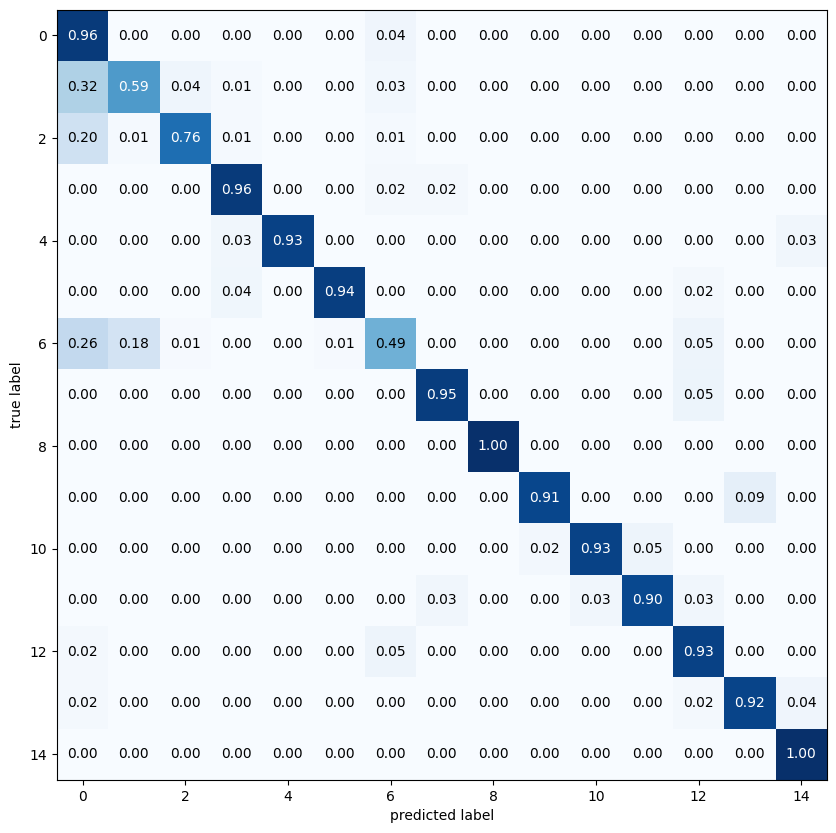

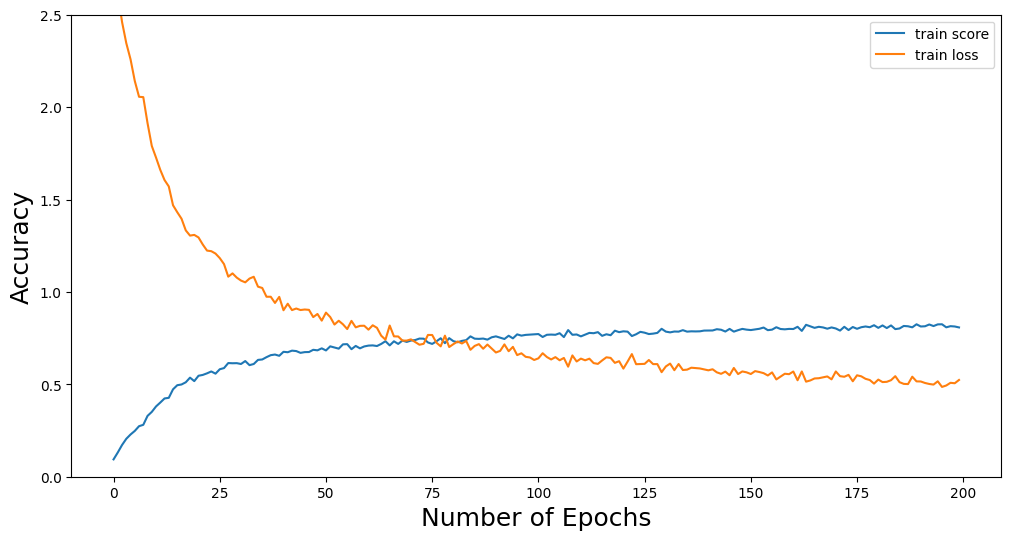

Train Data Shape: (2194, 300, 12)
Test Data Shape: (1084, 300, 12)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_35 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 31, 64)    │          0 │ conv1d_35[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 31, 64)    │          0 │ max_pooling1d_5[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_55[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_5         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_5[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_57          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_57[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 31, 256)   │          0 │ conv1d_36[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_37[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_31[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_31[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_60[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.0878 - loss: 3.0213
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.0983 - loss: 2.7362
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.1276 - loss: 2.6454
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.1503 - loss: 2.5616
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.1756 - loss: 2.4450
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.2108 - loss: 2.3295
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.2564 - loss: 2.2377
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.2699 - loss: 2.1493
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.2842 - loss: 2.0840
Epoch 10/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.2870 - loss: 2.0774
Epoch 11/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.3501 - loss: 1.9453
Epoch 12/200
35/35 ━━━━━━━━━━━━━━━━━━━

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9238 - loss: 0.2297
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8491 - loss: 0.6277
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
>#6: 
  train accuracy: 0.91522
  train loss    : 0.27229
  test accuracy: 0.82749
  test loss    : 0.75871

Accuracy: 0.82749 (+/-0.00000)
Loss: 0.75871 (+/-0.00000)


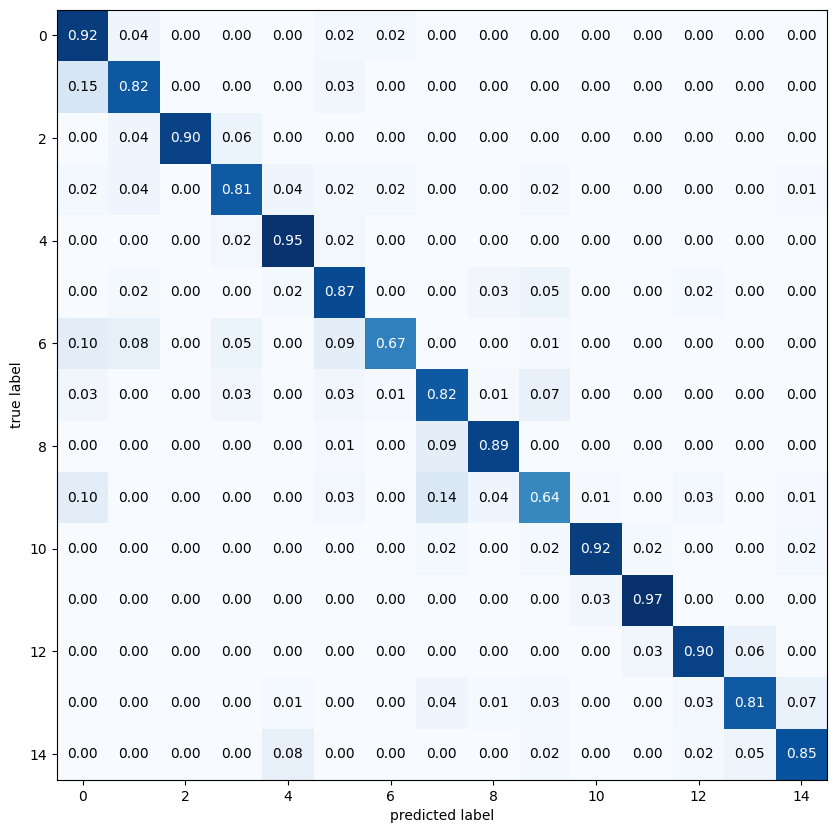

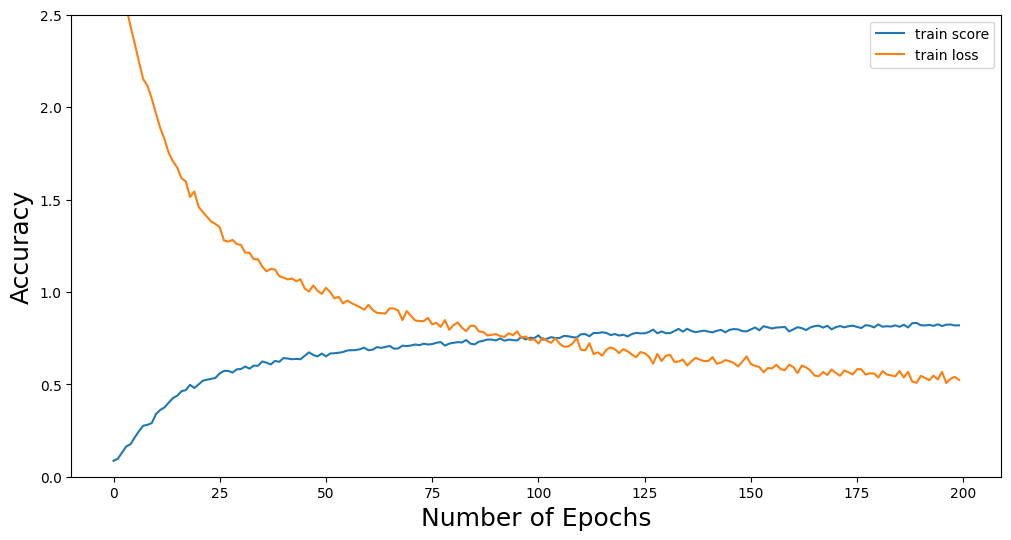

Train Data Shape: (2833, 300, 12)
Test Data Shape: (1446, 300, 12)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 31, 64)    │          0 │ conv1d_42[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 31, 64)    │          0 │ max_pooling1d_6[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_66[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_6         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_6[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_68          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_68[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_69          │ (None, 31, 256)   │          0 │ conv1d_43[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_69[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_44[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_37[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_71          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_71[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.0690 - loss: 2.9780
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.0690 - loss: 2.7868
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.1047 - loss: 2.7153
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.0952 - loss: 2.6554
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.1126 - loss: 2.6089
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.1303 - loss: 2.5716
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.1251 - loss: 2.5564
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.1396 - loss: 2.5493
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.1294 - loss: 2.4984
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.1528 - loss: 2.4640
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.1619 - loss: 2.4454
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8061 - loss: 0.4868
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6955 - loss: 1.1021
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
>#7: 
  train accuracy: 0.85634
  train loss    : 0.38623
  test accuracy: 0.74689
  test loss    : 0.90684

Accuracy: 0.74689 (+/-0.00000)
Loss: 0.90684 (+/-0.00000)


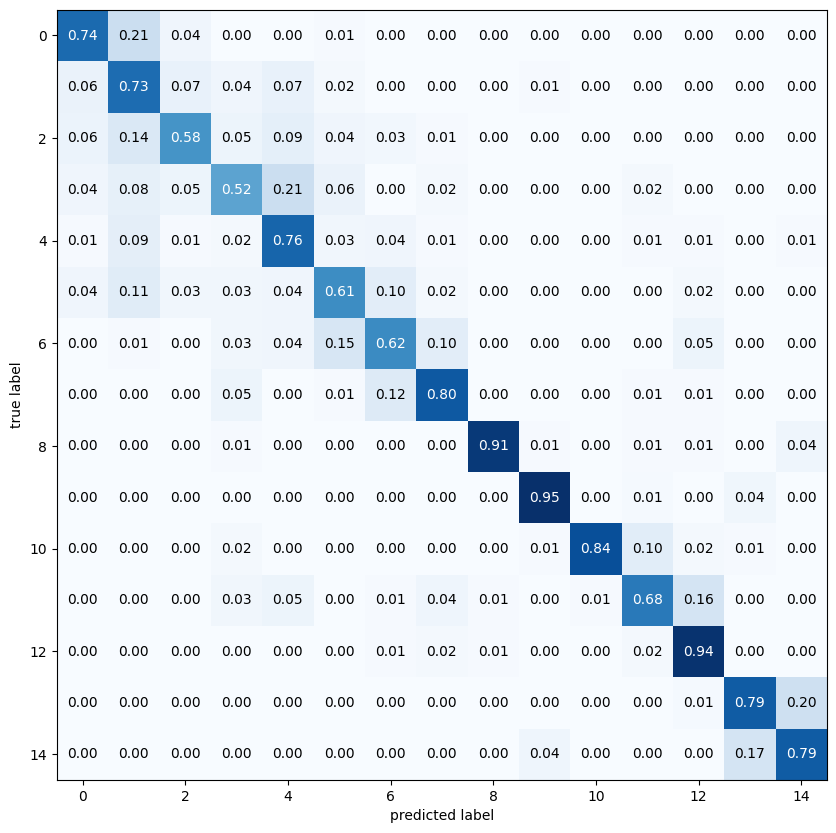

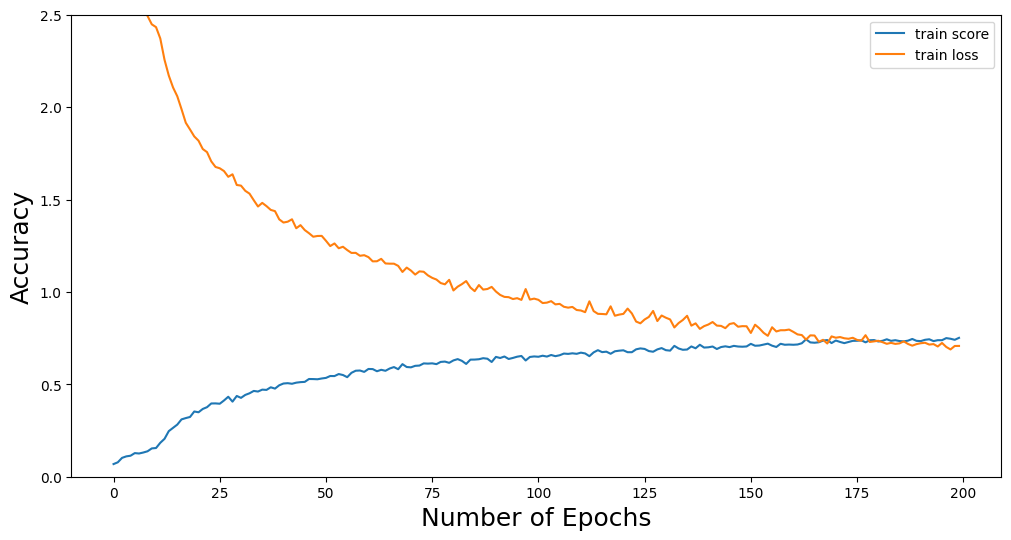

Train Data Shape: (1874, 300, 12)
Test Data Shape: (956, 300, 12)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 31, 64)    │          0 │ conv1d_49[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_77          │ (None, 31, 64)    │          0 │ max_pooling1d_7[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_77[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_7         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_7[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_79          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_79[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_42 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_42[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_80          │ (None, 31, 256)   │          0 │ conv1d_50[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_80[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_51[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_43 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_42[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_43[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_43[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_82          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_82[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.0797 - loss: 3.0668
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.1117 - loss: 2.7121
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.1467 - loss: 2.6035
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.1990 - loss: 2.4708
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.2410 - loss: 2.2999
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.2891 - loss: 2.1637
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3058 - loss: 2.0744
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3406 - loss: 1.9610
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.3765 - loss: 1.8544
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3762 - loss: 1.8391
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.4236 - loss: 1.7103
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9801 - loss: 0.0562
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8820 - loss: 0.5633
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
>#8: 
  train accuracy: 0.96692
  train loss    : 0.08450
  test accuracy: 0.84310
  test loss    : 0.72935

Accuracy: 0.84310 (+/-0.00000)
Loss: 0.72935 (+/-0.00000)


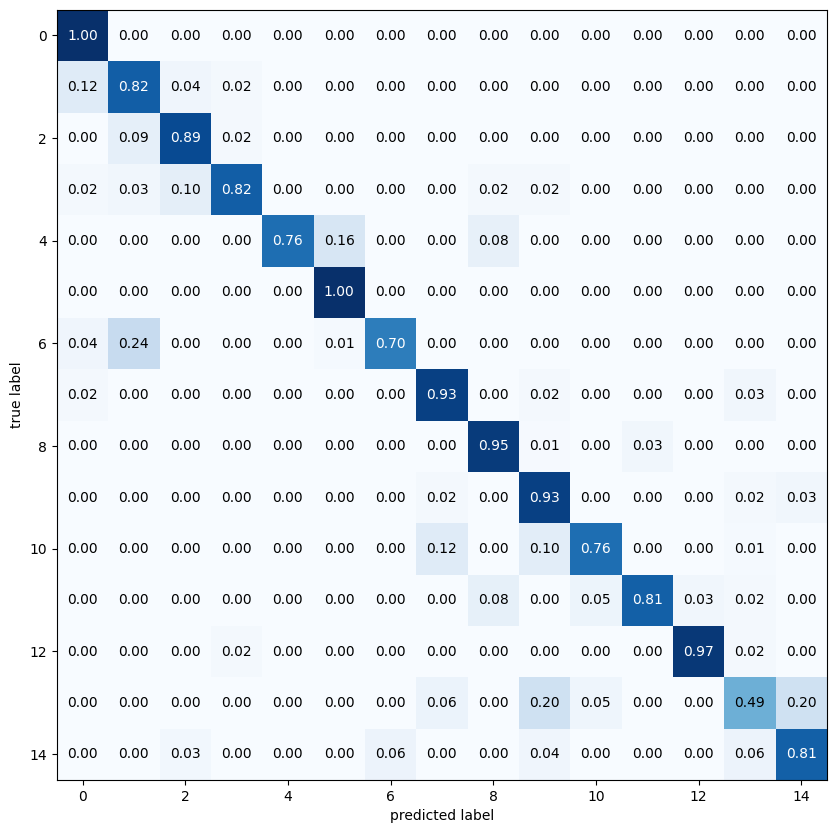

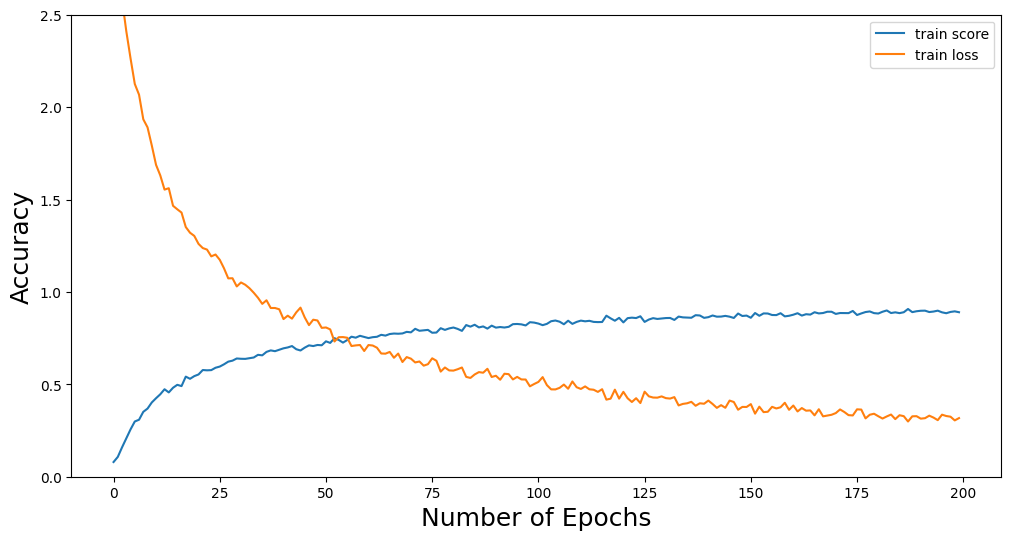

Train Data Shape: (1735, 300, 12)
Test Data Shape: (869, 300, 12)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_56 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 31, 64)    │          0 │ conv1d_56[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_88          │ (None, 31, 64)    │          0 │ max_pooling1d_8[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_88[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_8         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_8[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_90          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_90[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_48 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_57 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_48[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_91          │ (None, 31, 256)   │          0 │ conv1d_57[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_91[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_58[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_49 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_48[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_49[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_49[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_93          │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_93[0][0]

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.0954 - loss: 3.0845
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.1611 - loss: 2.6400
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.1819 - loss: 2.4422
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.2444 - loss: 2.3160
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.2686 - loss: 2.2061
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.3175 - loss: 2.0555
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.3379 - loss: 1.8980
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.3693 - loss: 1.8576
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.4174 - loss: 1.6569
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.4271 - loss: 1.6775
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.4345 - loss: 1.5809
Epoch 12/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9782 - loss: 0.0772
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9124 - loss: 0.4924
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
>#9: 
  train accuracy: 0.95158
  train loss    : 0.15816
  test accuracy: 0.87227
  test loss    : 0.60729

Accuracy: 0.87227 (+/-0.00000)
Loss: 0.60729 (+/-0.00000)


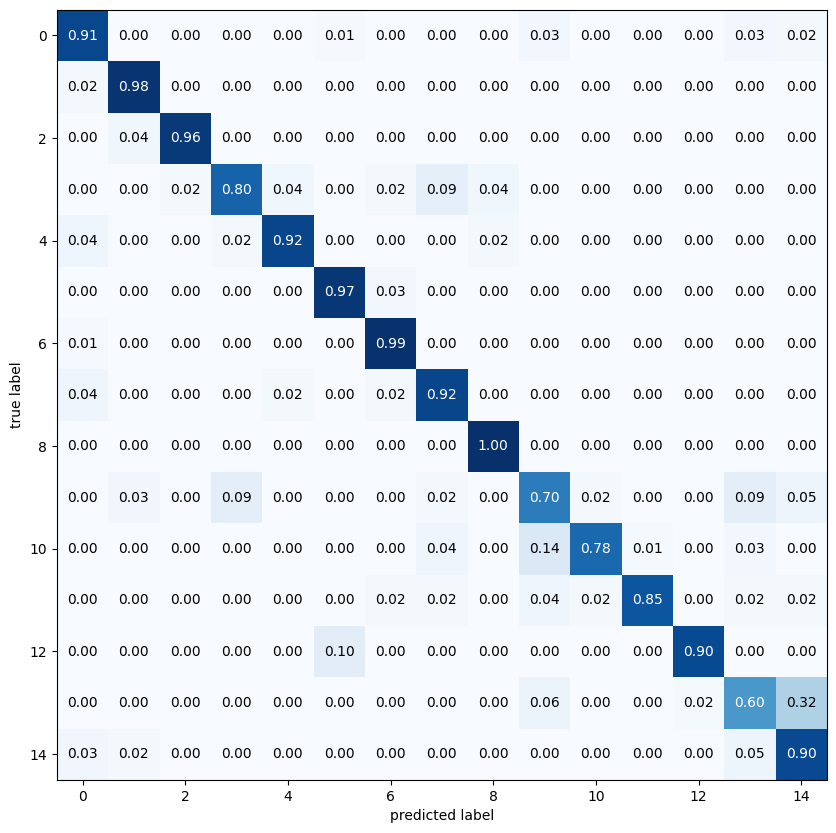

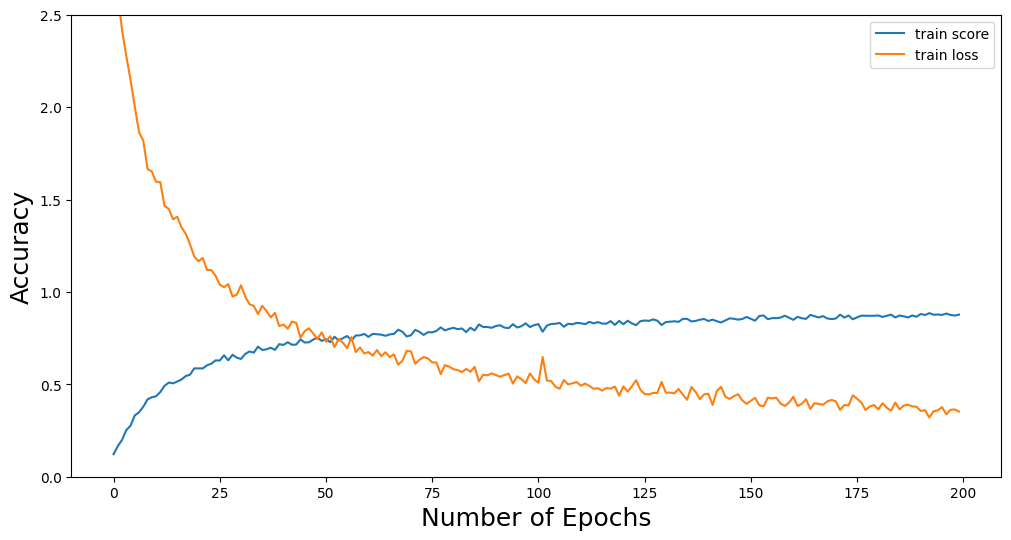

Train Data Shape: (1944, 300, 12)
Test Data Shape: (949, 300, 12)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_63 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 31, 64)    │          0 │ conv1d_63[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_99          │ (None, 31, 64)    │          0 │ max_pooling1d_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_99[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_9         │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_9[0][0… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_101         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_101[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_54[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_102         │ (None, 31, 256)   │          0 │ conv1d_64[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_65 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_102[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_65[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_55 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_54[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_55[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_55[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_104         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_104[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.0668 - loss: 3.1284
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.1074 - loss: 2.7129
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.1314 - loss: 2.6232
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.1161 - loss: 2.5994
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.1523 - loss: 2.5486
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.1642 - loss: 2.4453
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.2344 - loss: 2.2774
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.2983 - loss: 2.0547
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3569 - loss: 1.9107
Epoch 10/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.4051 - loss: 1.7299
Epoch 11/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.4357 - loss: 1.6390
Epoch 12/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9729 - loss: 0.0865
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8967 - loss: 0.4185
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
>#10: 
  train accuracy: 0.95679
  train loss    : 0.12976
  test accuracy: 0.86617
  test loss    : 0.63061

Accuracy: 0.86617 (+/-0.00000)
Loss: 0.63061 (+/-0.00000)


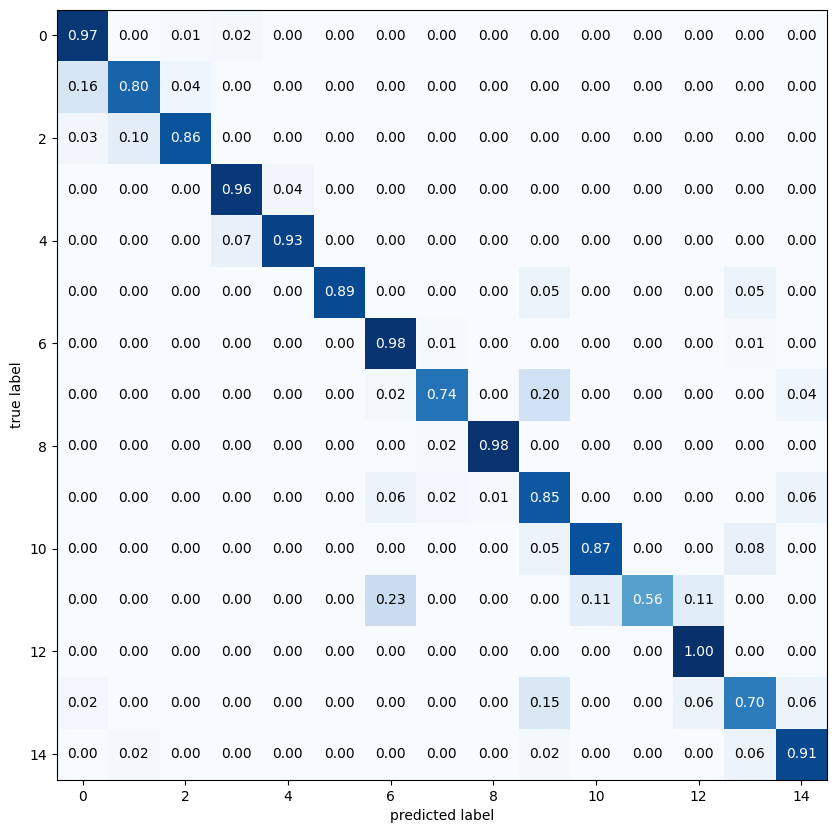

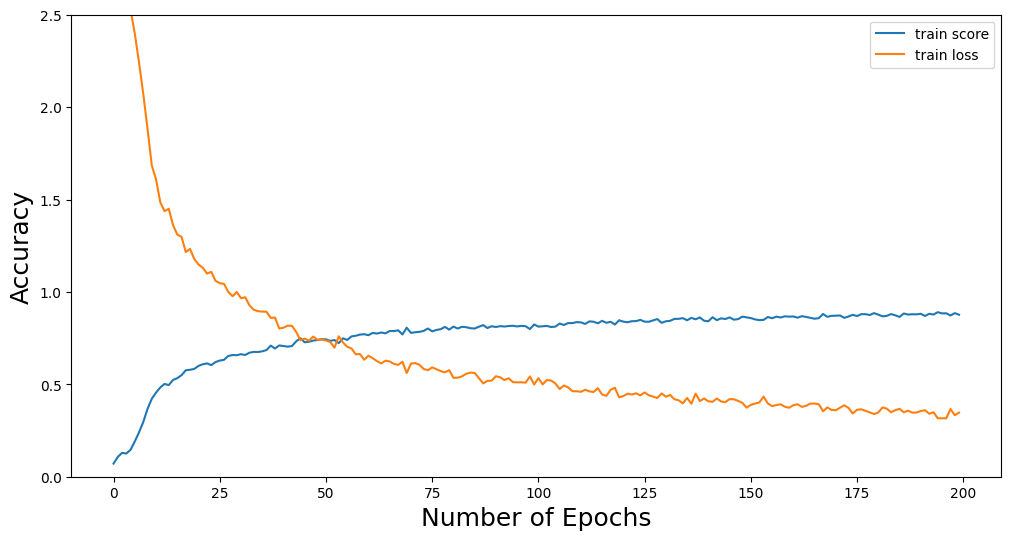

Train Data Shape: (3013, 300, 12)
Test Data Shape: (1509, 300, 12)


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 31, 64)    │          0 │ conv1d_70[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_110         │ (None, 31, 64)    │          0 │ max_pooling1d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_110[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_10        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_10[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_112         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_112[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_60 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_60[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_113         │ (None, 31, 256)   │          0 │ conv1d_71[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_113[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_72[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_61 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_60[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_61[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_61[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_115         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_115[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.0761 - loss: 2.9798
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.1014 - loss: 2.7268
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.1205 - loss: 2.6515
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.1416 - loss: 2.5554
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.1781 - loss: 2.4765
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.2272 - loss: 2.3528
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.2474 - loss: 2.2672
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.2805 - loss: 2.1795
Epoch 9/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.3390 - loss: 2.0291
Epoch 10/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.3358 - loss: 2.0141
Epoch 11/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.3592 - loss: 1.9172
Epoch 12/200
48/48 ━━━━━━━━━━━━━━━━━━━━

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8340 - loss: 0.4723
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7662 - loss: 0.8130
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
>#11: 
  train accuracy: 0.82476
  train loss    : 0.50631
  test accuracy: 0.76740
  test loss    : 0.78876

Accuracy: 0.76740 (+/-0.00000)
Loss: 0.78876 (+/-0.00000)


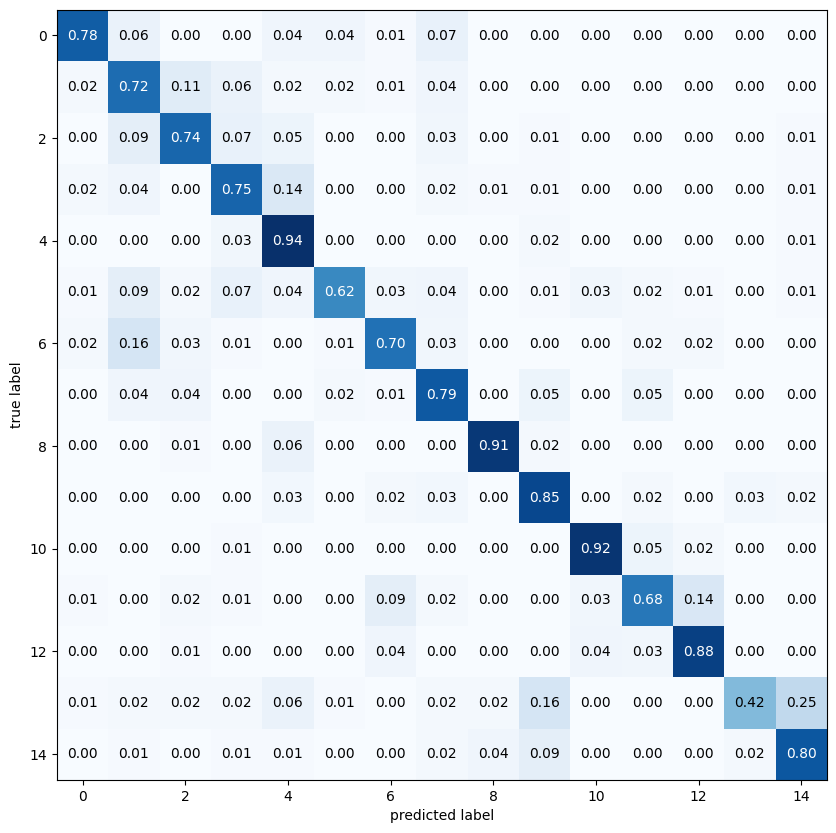

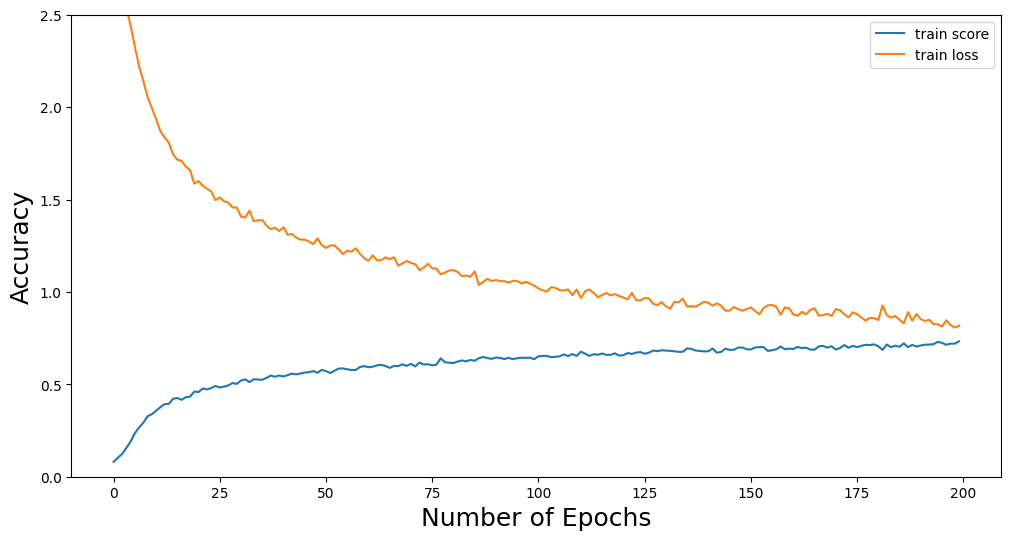

Train Data Shape: (2163, 300, 12)
Test Data Shape: (1119, 300, 12)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 31, 64)    │          0 │ conv1d_77[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_121         │ (None, 31, 64)    │          0 │ max_pooling1d_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_121[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_11        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_11[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_123         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_123[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_66 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_78 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_66[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_124         │ (None, 31, 256)   │          0 │ conv1d_78[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_79 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_124[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_79[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_67 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_66[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_67[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_67[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_126         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_126[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.0836 - loss: 2.9631
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.0986 - loss: 2.6927
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.1249 - loss: 2.6250
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.1101 - loss: 2.5571
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.1345 - loss: 2.5067
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.1357 - loss: 2.4694
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.1700 - loss: 2.3829
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.1864 - loss: 2.3238
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.1986 - loss: 2.3077
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.2001 - loss: 2.2582
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.2458 - loss: 2.1332
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9304 - loss: 0.1778
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8741 - loss: 0.4584
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
>#12: 
  train accuracy: 0.91771
  train loss    : 0.21449
  test accuracy: 0.83021
  test loss    : 0.68241

Accuracy: 0.83021 (+/-0.00000)
Loss: 0.68241 (+/-0.00000)


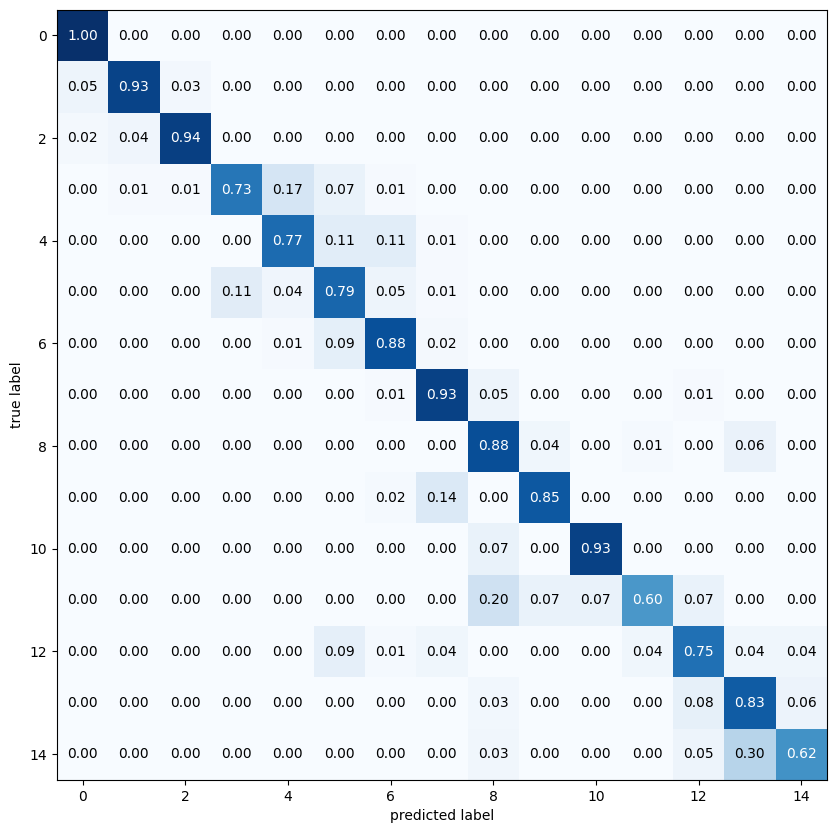

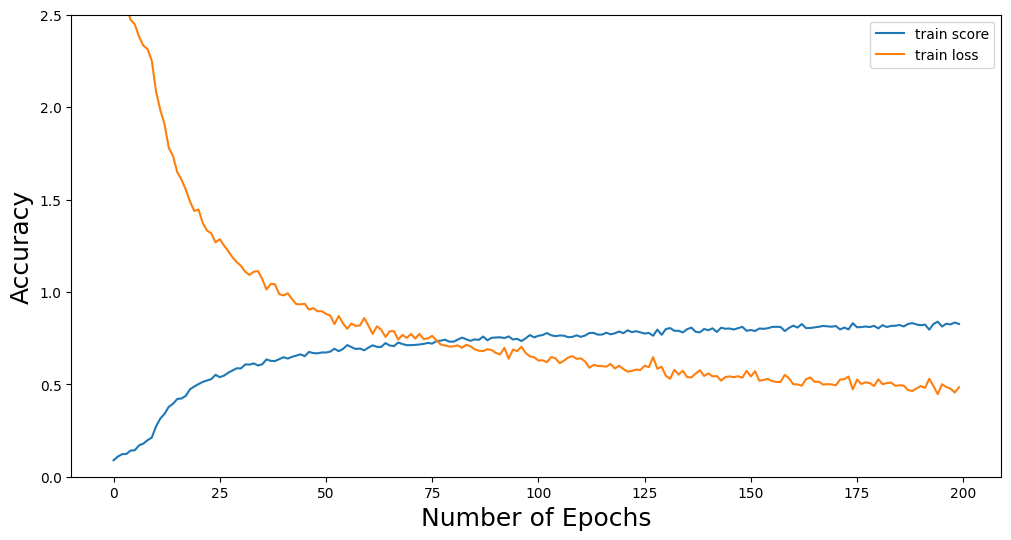

Train Data Shape: (1895, 300, 12)
Test Data Shape: (892, 300, 12)


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_84 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 31, 64)    │          0 │ conv1d_84[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_132         │ (None, 31, 64)    │          0 │ max_pooling1d_12… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_132[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_12        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_12[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_134         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_134[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_72 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_85 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_72[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_135         │ (None, 31, 256)   │          0 │ conv1d_85[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_86 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_135[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_86[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_73 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_72[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_73[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_73[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_137         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_137[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.0815 - loss: 3.2476
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.1084 - loss: 2.7702
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.1202 - loss: 2.6974
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.1141 - loss: 2.6813
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.1667 - loss: 2.6219
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1884 - loss: 2.5343
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.1972 - loss: 2.4632
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.2583 - loss: 2.3290
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.2429 - loss: 2.2787
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.2889 - loss: 2.2162
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.3121 - loss: 2.0676
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9547 - loss: 0.1326
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8344 - loss: 0.8791
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
>#13: 
  train accuracy: 0.93456
  train loss    : 0.18235
  test accuracy: 0.83184
  test loss    : 0.66334

Accuracy: 0.83184 (+/-0.00000)
Loss: 0.66334 (+/-0.00000)


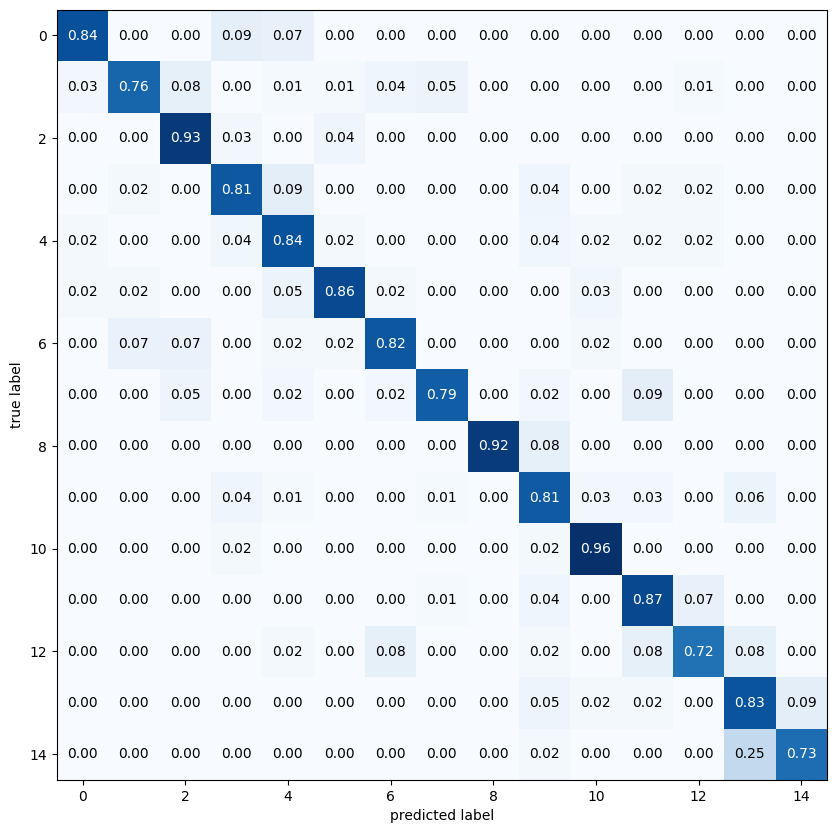

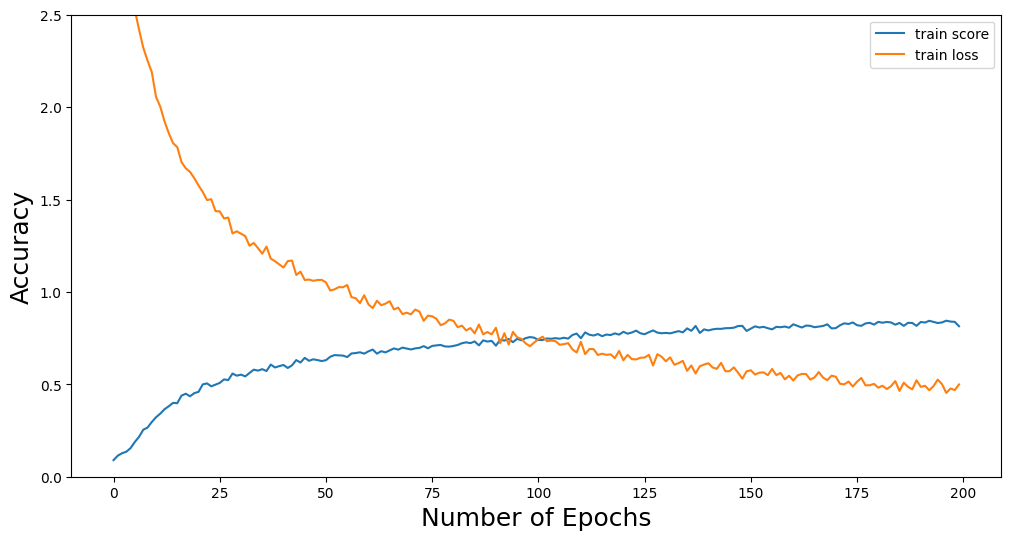

Train Data Shape: (2255, 300, 12)
Test Data Shape: (1098, 300, 12)


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_91 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 31, 64)    │          0 │ conv1d_91[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_143         │ (None, 31, 64)    │          0 │ max_pooling1d_13… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_143[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_13        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_13[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_145         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_145[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_78 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_92 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_78[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_146         │ (None, 31, 256)   │          0 │ conv1d_92[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_93 (Conv1D)  │ (None, 31, 65)    │     16,705 │ dropout_146[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_93[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_79 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_78[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_79[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_79[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_148         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_148[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.0785 - loss: 3.1014
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.1008 - loss: 2.6886
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.1340 - loss: 2.5870
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.1172 - loss: 2.5593
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.1253 - loss: 2.5043
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.1327 - loss: 2.5113
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.1439 - loss: 2.4453
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.1337 - loss: 2.4387
Epoch 9/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.1553 - loss: 2.4004
Epoch 10/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.1522 - loss: 2.3796
Epoch 11/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.1602 - loss: 2.3460
Epoch 12/200
36/36 ━━━━━━━━━━━━━━━━━━

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8026 - loss: 0.5173
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7217 - loss: 0.7981
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
>#14: 
  train accuracy: 0.81064
  train loss    : 0.51694
  test accuracy: 0.72495
  test loss    : 0.82531

Accuracy: 0.72495 (+/-0.00000)
Loss: 0.82531 (+/-0.00000)


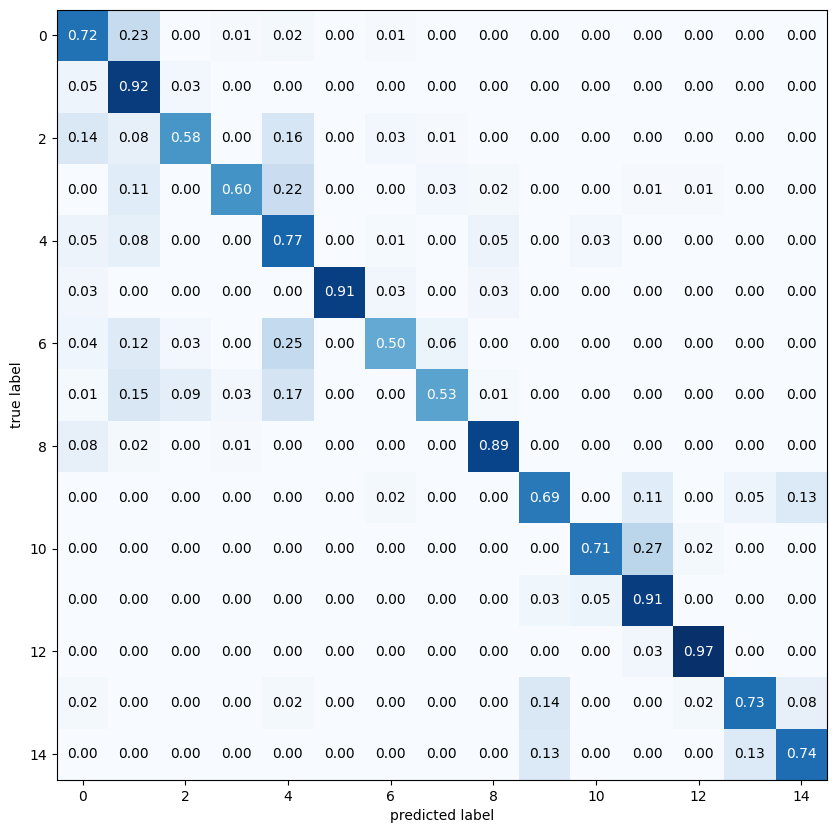

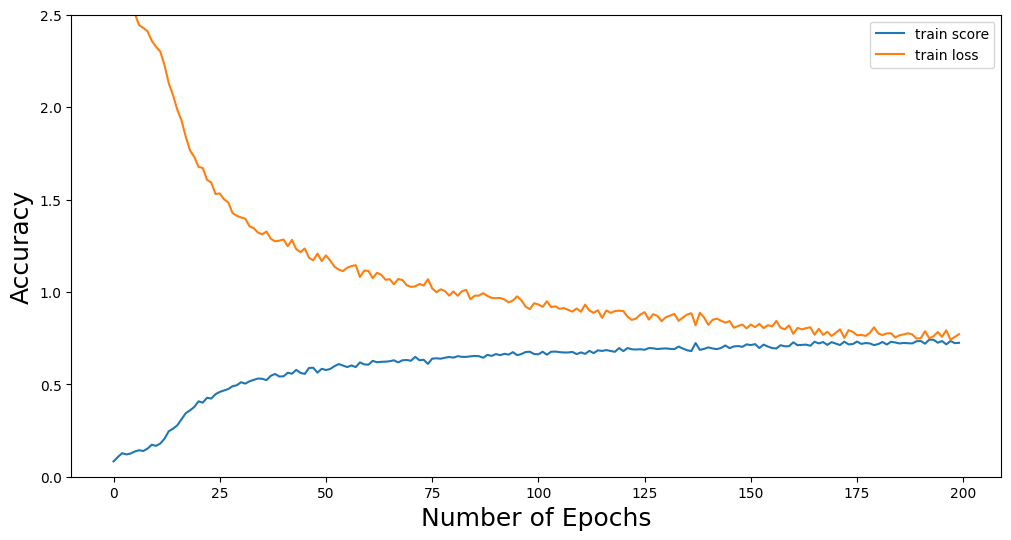

Train Data Shape: (1916, 300, 12)
Test Data Shape: (935, 300, 12)


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_98 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 31, 64)    │          0 │ conv1d_98[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_154         │ (None, 31, 64)    │          0 │ max_pooling1d_14… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_154[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_14        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_14[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_156         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_156[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_84 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_99 (Conv1D)  │ (None, 31, 256)   │     16,896 │ add_84[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_157         │ (None, 31, 256)   │          0 │ conv1d_99[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_100 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_157[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_100[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_85 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_84[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_85[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_85[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_159         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_159[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.1008 - loss: 3.0332
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.1446 - loss: 2.5881
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.1350 - loss: 2.4934
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.1564 - loss: 2.4708
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.1765 - loss: 2.4127
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1625 - loss: 2.3897
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.2036 - loss: 2.3028
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.2070 - loss: 2.2644
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.2418 - loss: 2.1657
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.2455 - loss: 2.0889
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.2964 - loss: 2.0393
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9209 - loss: 0.2248
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8558 - loss: 0.5507
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
>#15: 
  train accuracy: 0.93111
  train loss    : 0.20177
  test accuracy: 0.83636
  test loss    : 0.69866

Accuracy: 0.83636 (+/-0.00000)
Loss: 0.69866 (+/-0.00000)


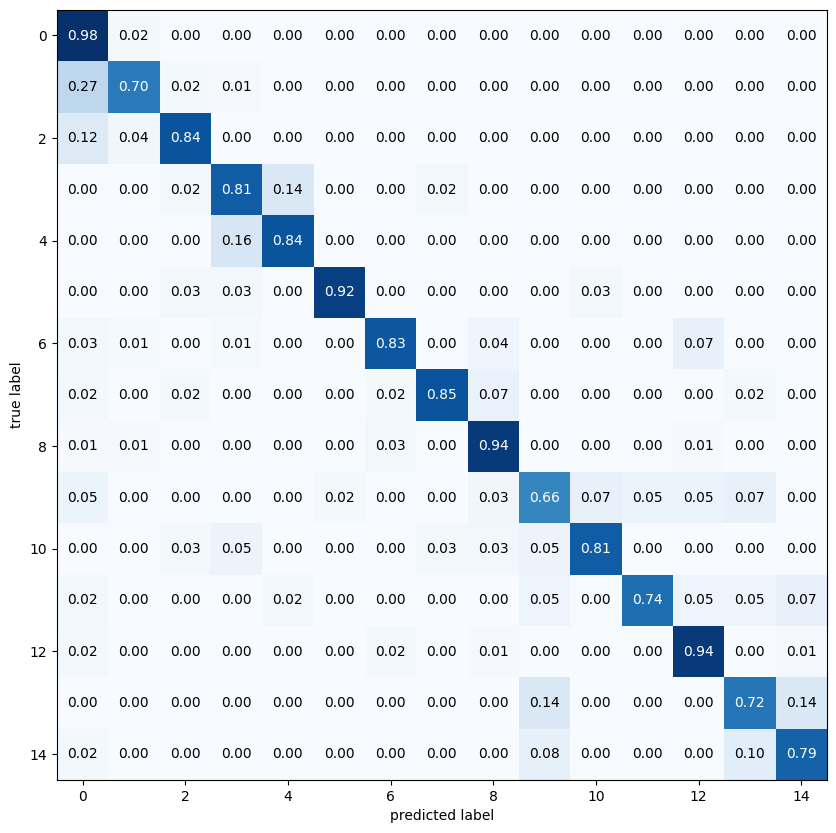

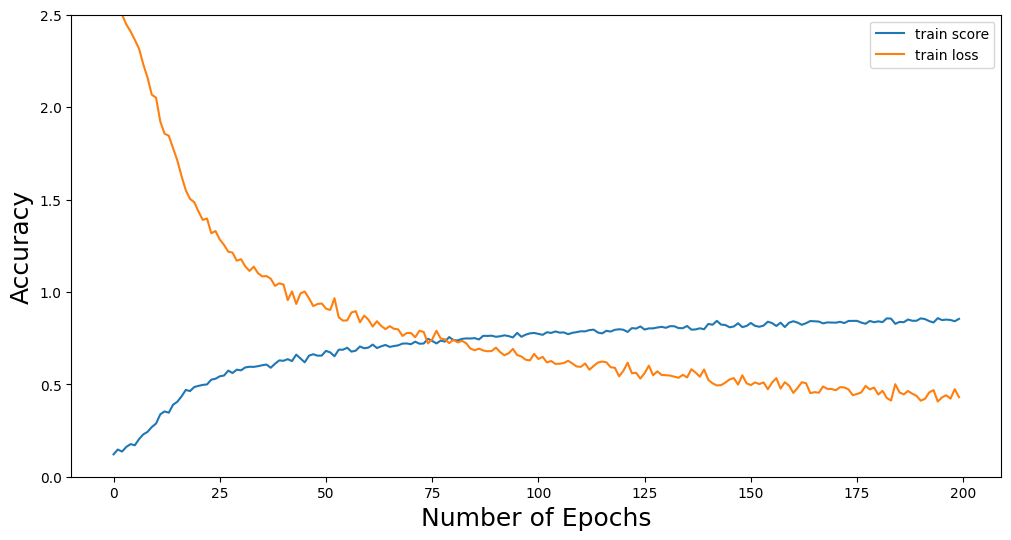

Train Data Shape: (1806, 300, 12)
Test Data Shape: (847, 300, 12)


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_105 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 31, 64)    │          0 │ conv1d_105[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_165         │ (None, 31, 64)    │          0 │ max_pooling1d_15… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_165[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_15        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_15[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_167         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_167[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_90 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_106 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_90[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_168         │ (None, 31, 256)   │          0 │ conv1d_106[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_107 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_168[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_107[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_91 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_90[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_91[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_91[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_170         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_170[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - accuracy: 0.0596 - loss: 3.0123
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.1149 - loss: 2.7050
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.1261 - loss: 2.6245
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.1799 - loss: 2.4582
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.1994 - loss: 2.4033
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.2315 - loss: 2.3328
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.2621 - loss: 2.2213
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.2873 - loss: 2.1017
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.2861 - loss: 2.0705
Epoch 10/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.3077 - loss: 2.0888
Epoch 11/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.3196 - loss: 1.9713
Epoch 12/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9533 - loss: 0.1304
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8294 - loss: 0.6671
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
>#16: 
  train accuracy: 0.91307
  train loss    : 0.22756
  test accuracy: 0.77332
  test loss    : 0.75137

Accuracy: 0.77332 (+/-0.00000)
Loss: 0.75137 (+/-0.00000)


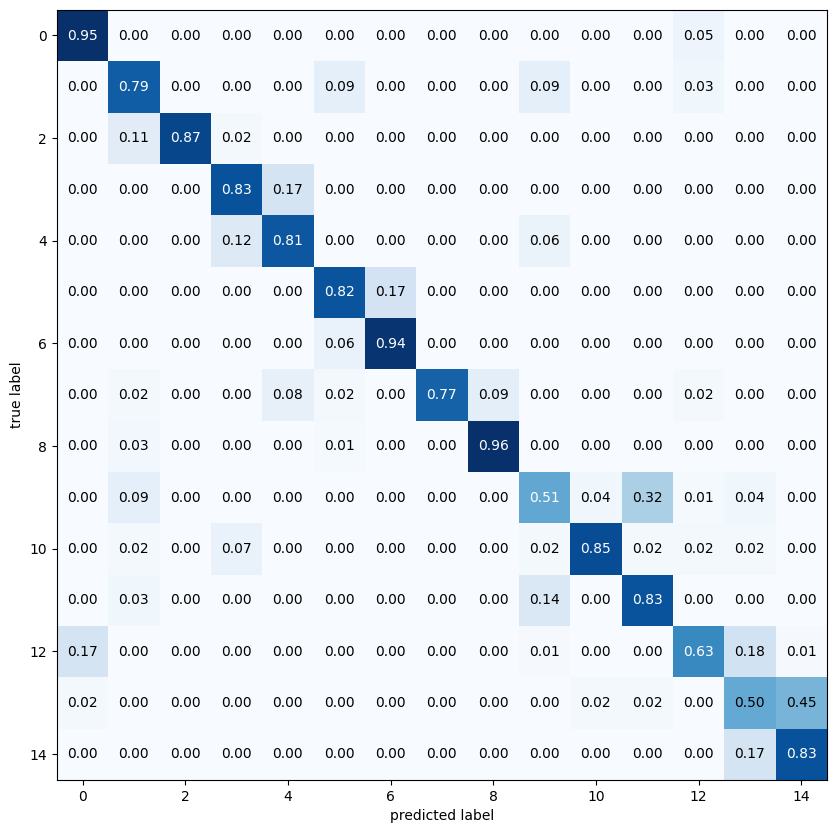

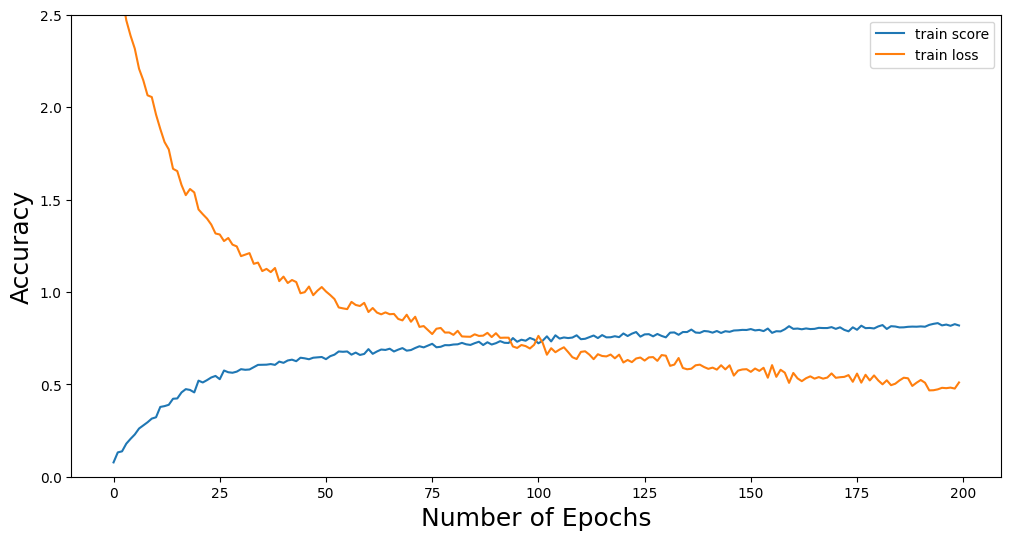

Train Data Shape: (2623, 300, 12)
Test Data Shape: (1315, 300, 12)


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_112 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_16    │ (None, 31, 64)    │          0 │ conv1d_112[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_176         │ (None, 31, 64)    │          0 │ max_pooling1d_16… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_176[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_16        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_16[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_178         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_178[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_96 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_113 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_96[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_179         │ (None, 31, 256)   │          0 │ conv1d_113[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_114 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_179[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_114[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_97 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_96[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_97[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_97[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_181         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_181[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - accuracy: 0.0691 - loss: 2.9714
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.0936 - loss: 2.7456
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.1141 - loss: 2.6567
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.1285 - loss: 2.6182
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 167ms/step - accuracy: 0.1649 - loss: 2.5079
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.1959 - loss: 2.4143
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.2699 - loss: 2.2088
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.3228 - loss: 2.0023
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.3650 - loss: 1.9047
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.3836 - loss: 1.7882
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.4257 - loss: 1.6565
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9413 - loss: 0.1584
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8930 - loss: 0.4402
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step
>#17: 
  train accuracy: 0.93176
  train loss    : 0.19013
  test accuracy: 0.86692
  test loss    : 0.54851

Accuracy: 0.86692 (+/-0.00000)
Loss: 0.54851 (+/-0.00000)


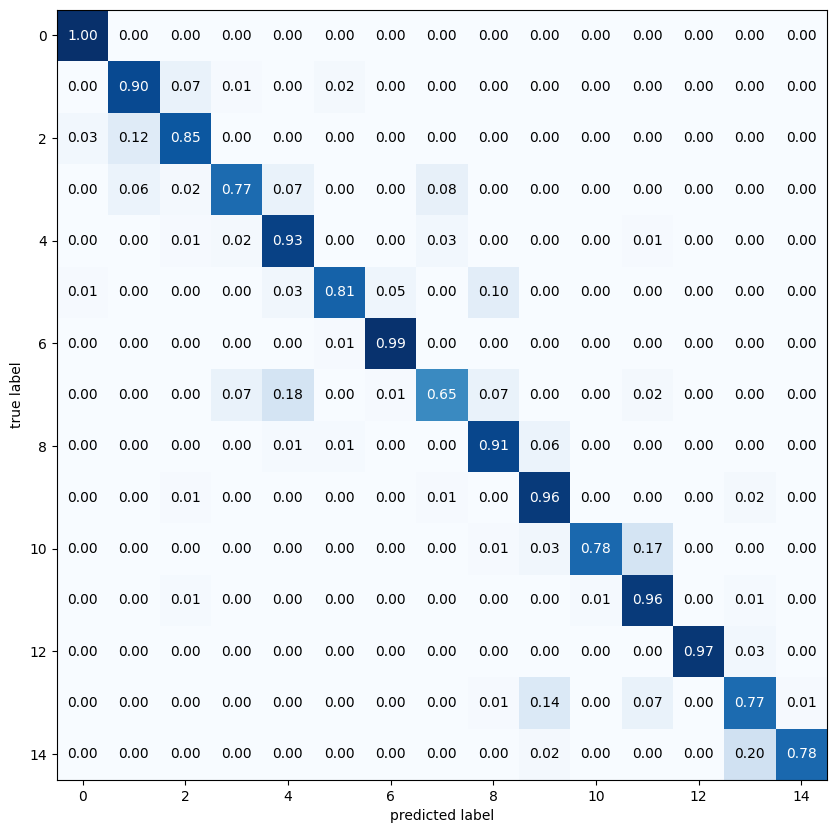

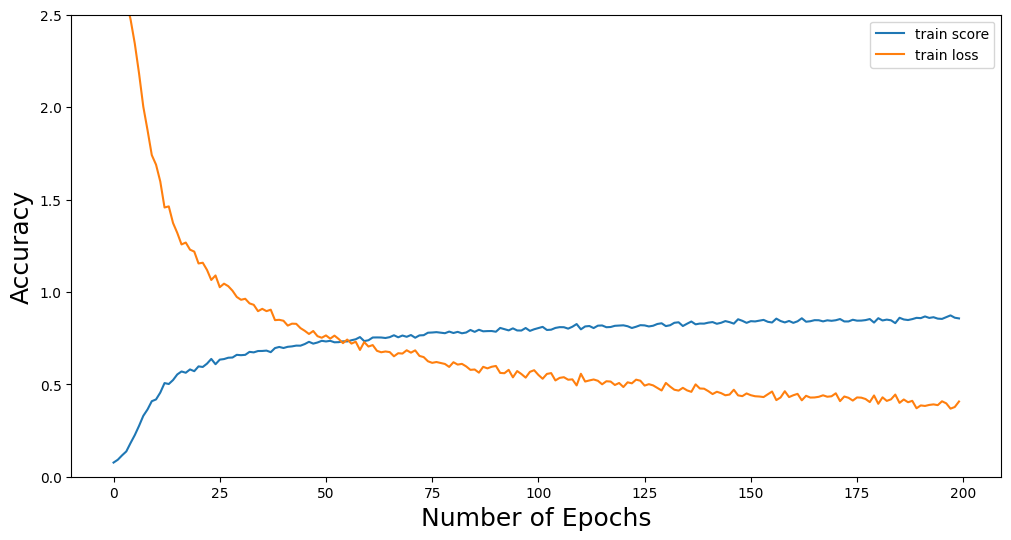

Train Data Shape: (2371, 300, 12)
Test Data Shape: (1109, 300, 12)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_119 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_17    │ (None, 31, 64)    │          0 │ conv1d_119[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_187         │ (None, 31, 64)    │          0 │ max_pooling1d_17… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_187[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_17        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_17[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_189         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_189[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_102 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_120 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_102[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_190         │ (None, 31, 256)   │          0 │ conv1d_120[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_121 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_190[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_121[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_103 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_102[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_103[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_103[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_192         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_192[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.0665 - loss: 3.0205
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.1168 - loss: 2.7378
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.1137 - loss: 2.6400
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.1466 - loss: 2.5762
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.1744 - loss: 2.4806
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.2131 - loss: 2.3378
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.2624 - loss: 2.2472
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.2866 - loss: 2.1828
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.3213 - loss: 2.0306
Epoch 10/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 0.3088 - loss: 2.0374
Epoch 11/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.3266 - loss: 2.0176
Epoch 12/200
38/38 ━━━━━━━━━━━━━━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8797 - loss: 0.3290
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8260 - loss: 0.5812
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
>#18: 
  train accuracy: 0.86546
  train loss    : 0.36737
  test accuracy: 0.79531
  test loss    : 0.73004

Accuracy: 0.79531 (+/-0.00000)
Loss: 0.73004 (+/-0.00000)


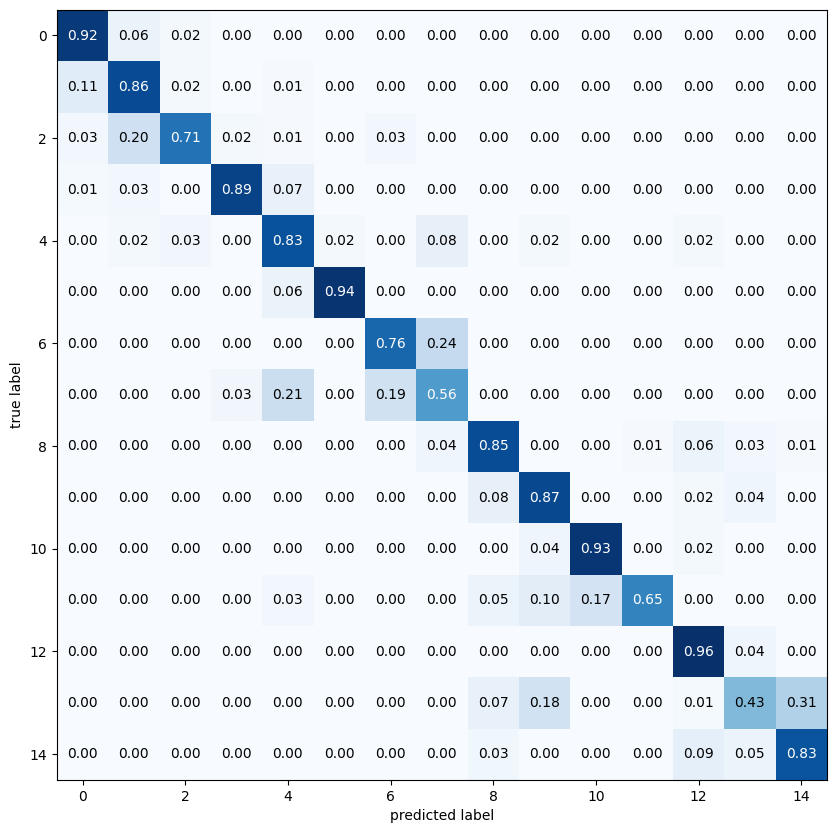

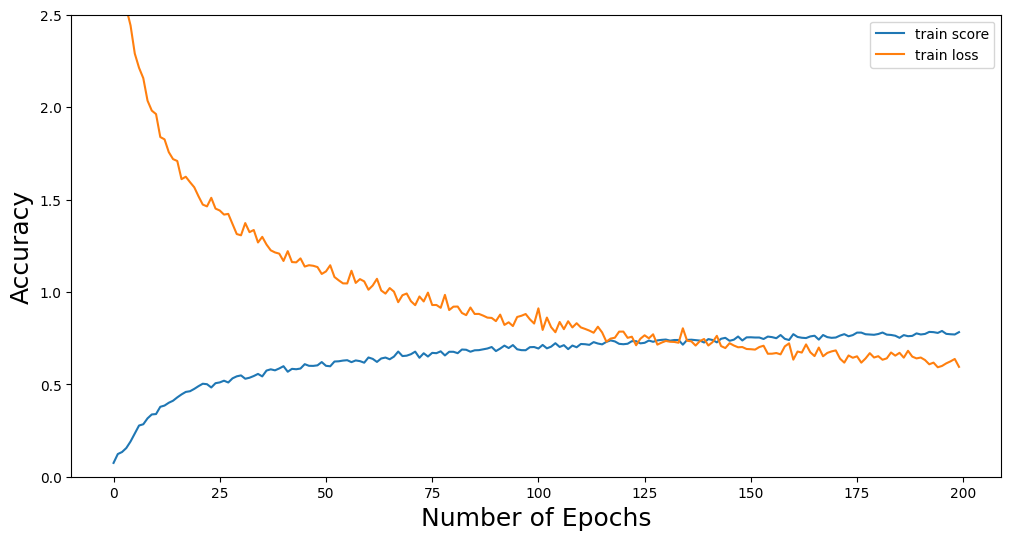

Train Data Shape: (2416, 300, 12)
Test Data Shape: (1232, 300, 12)


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_126 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 31, 64)    │          0 │ conv1d_126[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_198         │ (None, 31, 64)    │          0 │ max_pooling1d_18… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_198[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_18        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_18[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_200         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_200[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_108 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_127 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_108[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_201         │ (None, 31, 256)   │          0 │ conv1d_127[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_128 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_201[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_128[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_109 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_108[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_109[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_109[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_203         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_203[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step - accuracy: 0.0844 - loss: 3.0522
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.0956 - loss: 2.7455
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.1069 - loss: 2.6606
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.1570 - loss: 2.5604
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.1857 - loss: 2.4507
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.1757 - loss: 2.4038
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.2223 - loss: 2.2682
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.2680 - loss: 2.1884
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.2806 - loss: 2.0929
Epoch 10/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.2952 - loss: 2.0438
Epoch 11/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.3170 - loss: 1.9642
Epoch 12/200
38/38 ━━━━━━━━━━━━━━━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9270 - loss: 0.2089
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8122 - loss: 0.7270
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step
>#19: 
  train accuracy: 0.90439
  train loss    : 0.27020
  test accuracy: 0.80276
  test loss    : 0.72493

Accuracy: 0.80276 (+/-0.00000)
Loss: 0.72493 (+/-0.00000)


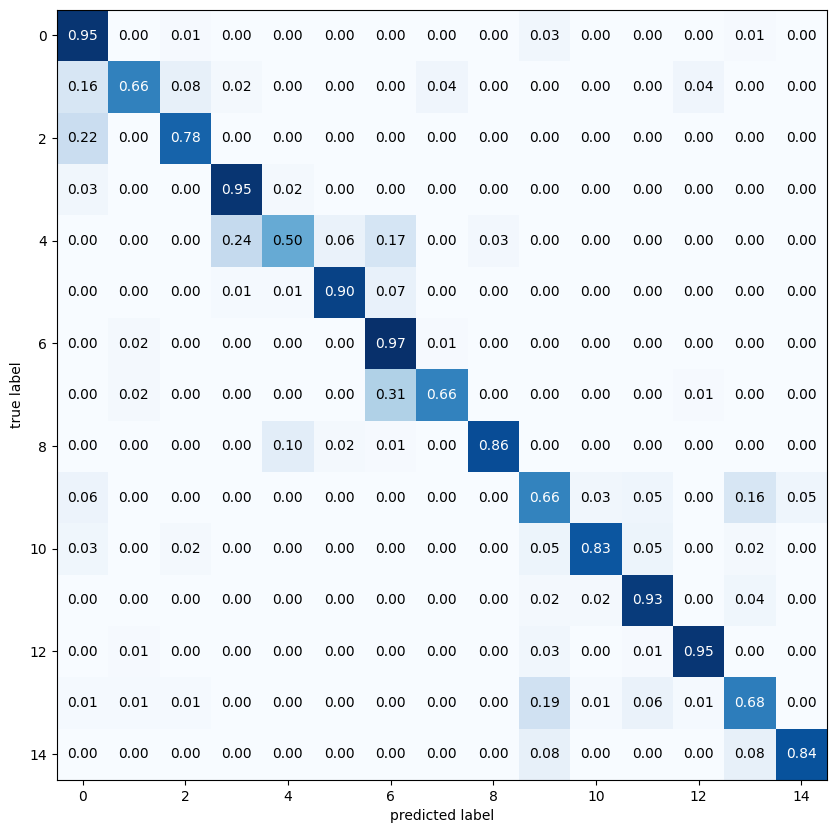

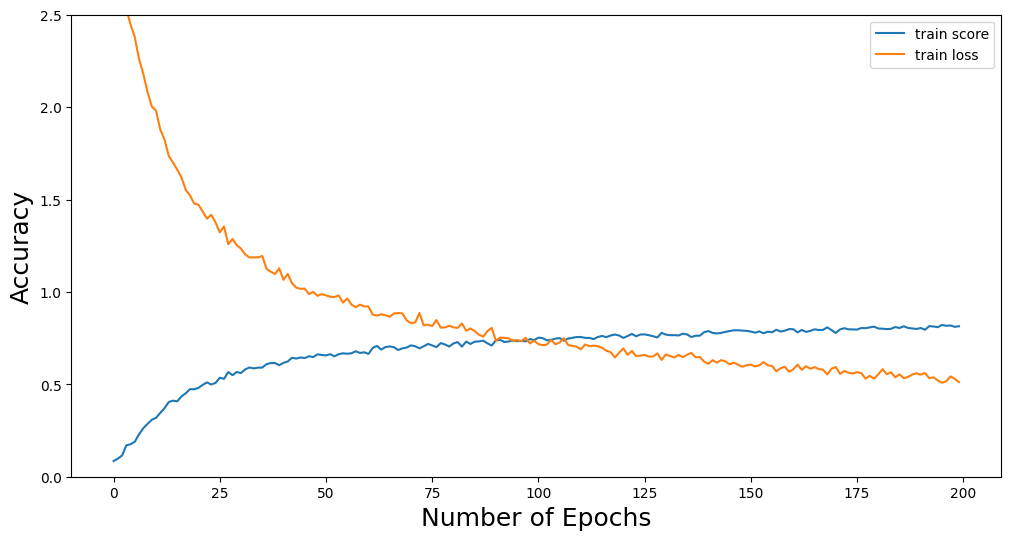

Train Data Shape: (2070, 300, 12)
Test Data Shape: (1018, 300, 12)


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_133 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 31, 64)    │          0 │ conv1d_133[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_209         │ (None, 31, 64)    │          0 │ max_pooling1d_19… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_209[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_19        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_19[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_211         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_211[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_114 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_134 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_114[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_212         │ (None, 31, 256)   │          0 │ conv1d_134[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_135 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_212[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_135[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_115 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_114[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_115[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_115[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_214         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_214[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.0913 - loss: 2.9563
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.1428 - loss: 2.6024
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.2159 - loss: 2.4471
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.2728 - loss: 2.2362
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.3076 - loss: 2.0990
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.3288 - loss: 2.0294
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.3685 - loss: 1.9256
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.3624 - loss: 1.8892
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.4264 - loss: 1.7604
Epoch 10/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.4280 - loss: 1.7177
Epoch 11/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.4668 - loss: 1.6150
Epoch 12/200
33/33 ━━━━━━━━━━━━━━━━━━━

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8930 - loss: 0.3033
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8655 - loss: 0.5140
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
>#20: 
  train accuracy: 0.90773
  train loss    : 0.26885
  test accuracy: 0.84479
  test loss    : 0.67059

Accuracy: 0.84479 (+/-0.00000)
Loss: 0.67059 (+/-0.00000)


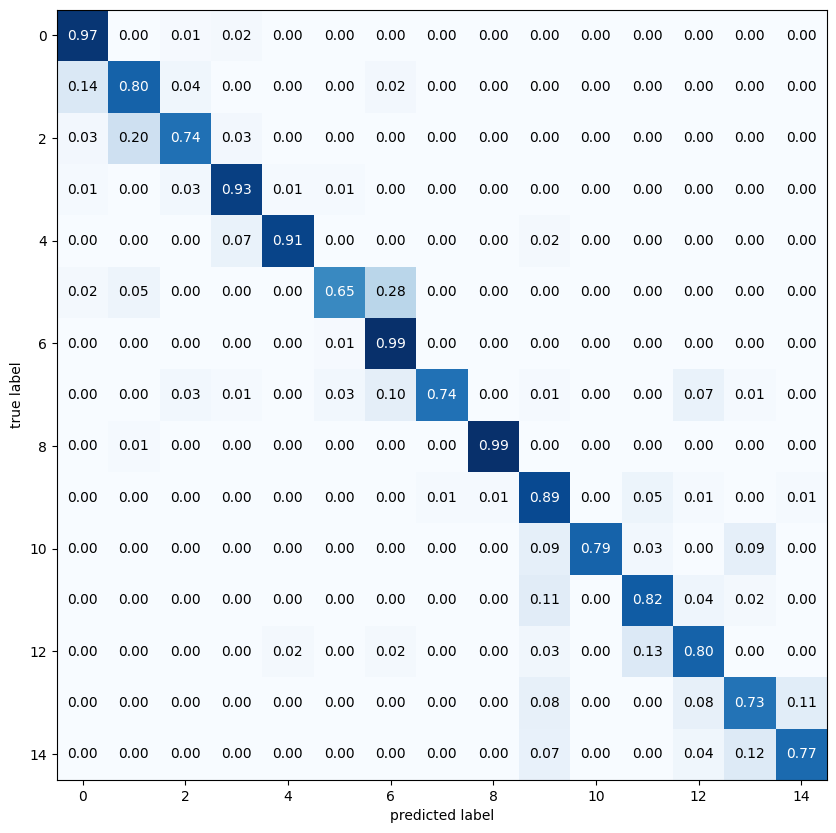

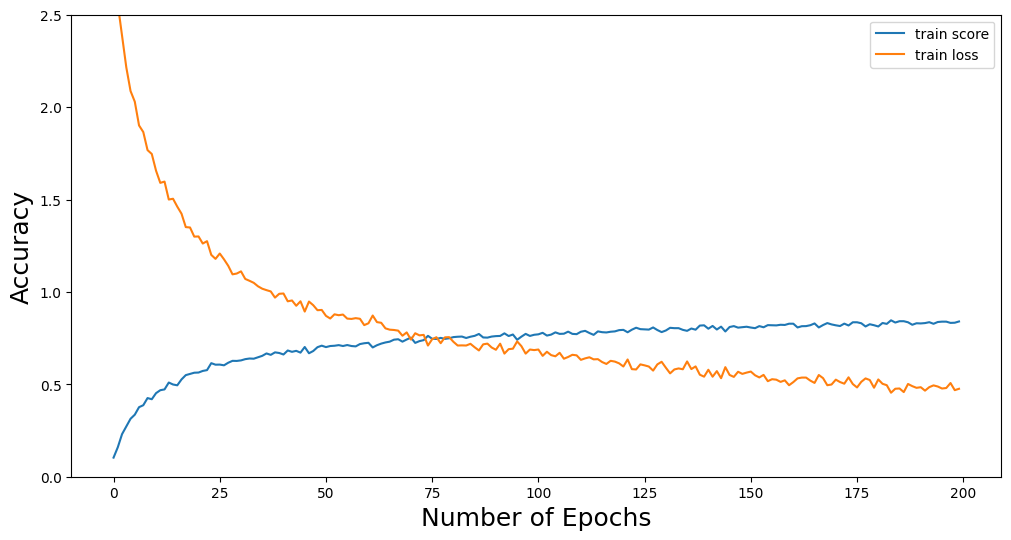

Train Data Shape: (1842, 300, 12)
Test Data Shape: (950, 300, 12)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_140 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_20    │ (None, 31, 64)    │          0 │ conv1d_140[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_220         │ (None, 31, 64)    │          0 │ max_pooling1d_20… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_220[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_20        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_20[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_222         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_222[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_120 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_141 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_120[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_223         │ (None, 31, 256)   │          0 │ conv1d_141[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_142 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_223[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_142[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_121 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_120[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_121[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_121[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_225         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_225[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.1148 - loss: 2.9385
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.1725 - loss: 2.5499
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.2141 - loss: 2.3768
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.2293 - loss: 2.2822
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.2891 - loss: 2.1310
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.3182 - loss: 2.0470
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.3219 - loss: 1.9701
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.3384 - loss: 1.9241
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.3975 - loss: 1.8077
Epoch 10/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.3982 - loss: 1.7585
Epoch 11/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.3904 - loss: 1.7379
Epoch 12/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9183 - loss: 0.2570
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7526 - loss: 1.0264
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
>#21: 
  train accuracy: 0.89034
  train loss    : 0.32580
  test accuracy: 0.72526
  test loss    : 1.04429

Accuracy: 0.72526 (+/-0.00000)
Loss: 1.04429 (+/-0.00000)


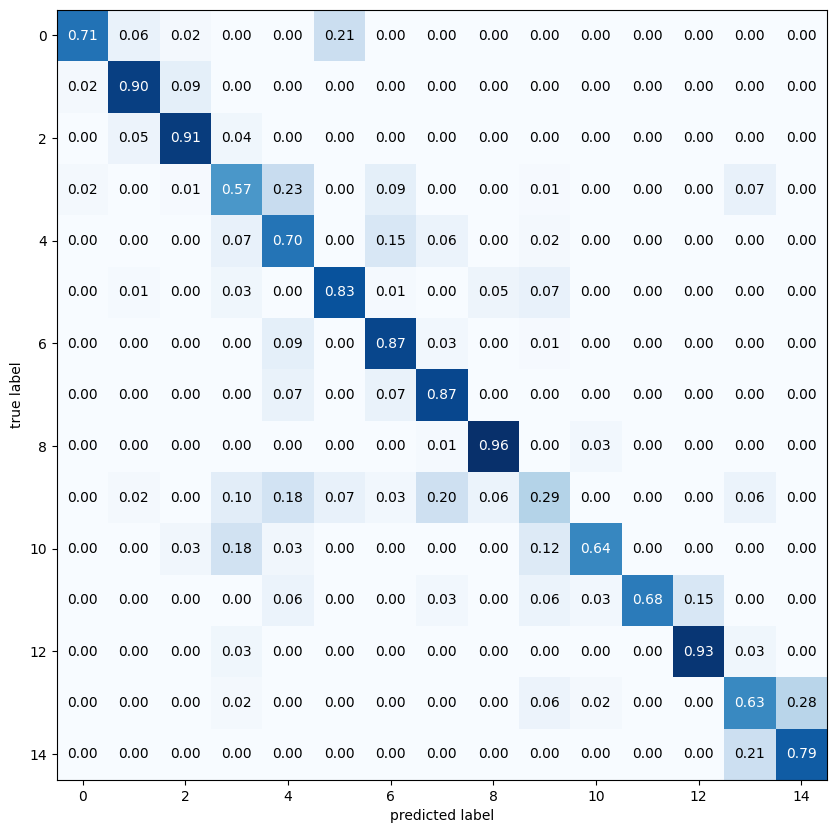

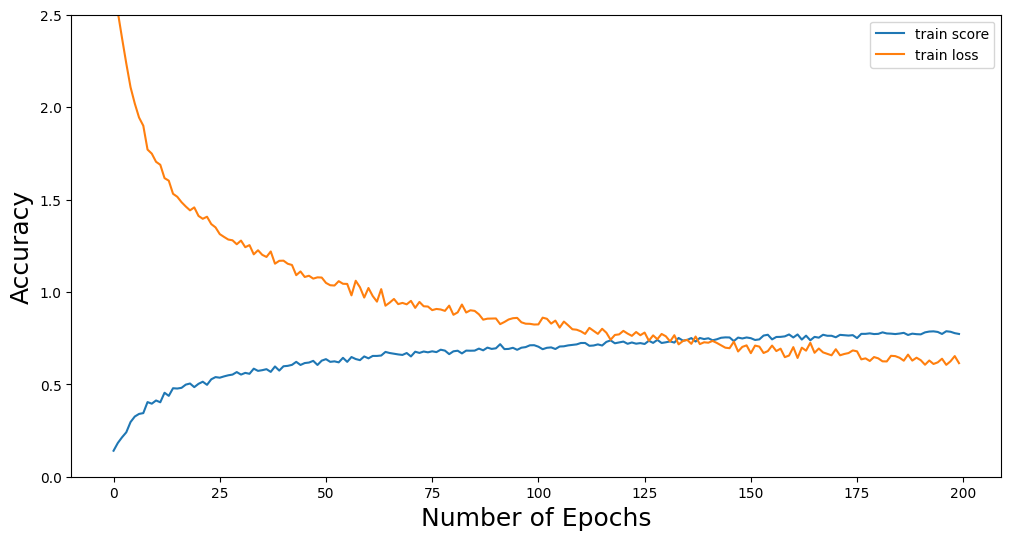

Train Data Shape: (1917, 300, 12)
Test Data Shape: (991, 300, 12)


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_147 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_21    │ (None, 31, 64)    │          0 │ conv1d_147[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_231         │ (None, 31, 64)    │          0 │ max_pooling1d_21… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_231[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_21        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_21[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_21[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_233         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_233[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_126 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_21[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_148 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_126[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_234         │ (None, 31, 256)   │          0 │ conv1d_148[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_149 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_234[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_149[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_127 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_126[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_127[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_127[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_236         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_236[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.0807 - loss: 3.0798
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.0948 - loss: 2.7076
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.1068 - loss: 2.6929
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.1520 - loss: 2.6180
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.1631 - loss: 2.5662
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.1792 - loss: 2.5167
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.1721 - loss: 2.4970
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.1807 - loss: 2.4281
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.1830 - loss: 2.4461
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.2076 - loss: 2.3504
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.2452 - loss: 2.2945
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9748 - loss: 0.0626
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8751 - loss: 0.6272
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
>#22: 
  train accuracy: 0.97496
  train loss    : 0.07206
  test accuracy: 0.83956
  test loss    : 0.85961

Accuracy: 0.83956 (+/-0.00000)
Loss: 0.85961 (+/-0.00000)


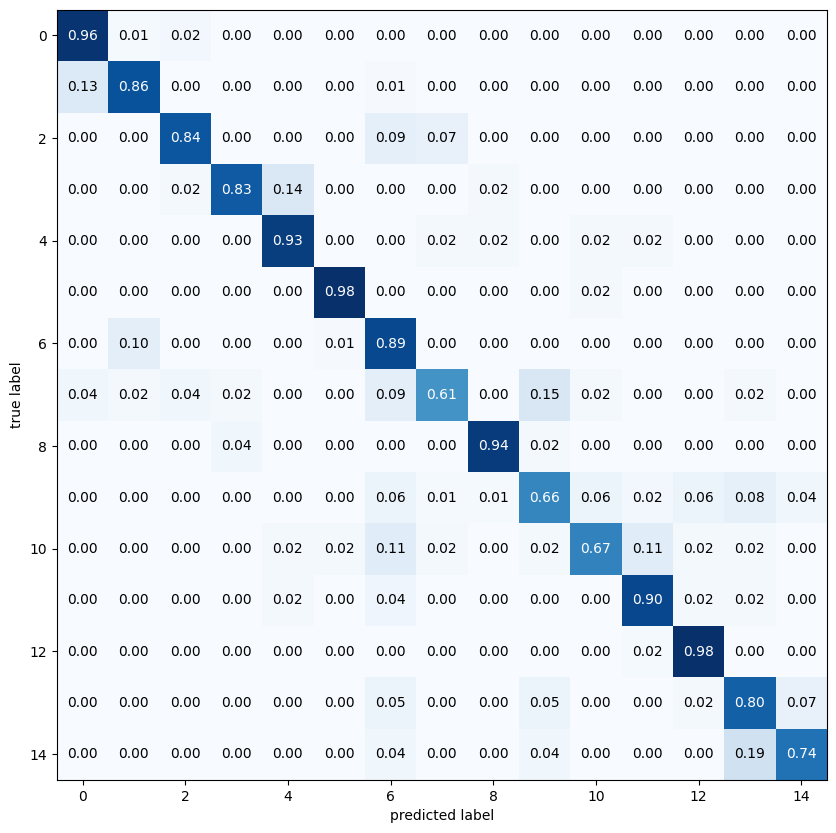

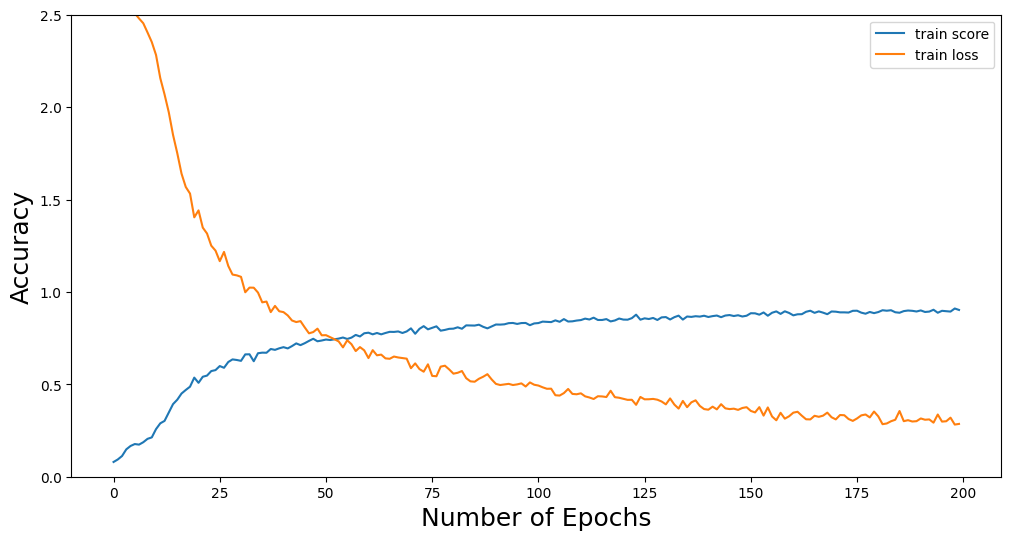

Train Data Shape: (2402, 300, 12)
Test Data Shape: (1192, 300, 12)


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_154 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_22    │ (None, 31, 64)    │          0 │ conv1d_154[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_242         │ (None, 31, 64)    │          0 │ max_pooling1d_22… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_242[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_22        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_22[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_22[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_244         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_244[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_132 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_22[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_155 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_132[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_245         │ (None, 31, 256)   │          0 │ conv1d_155[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_156 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_245[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_156[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_133 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_132[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_133[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_133[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_247         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_247[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 186ms/step - accuracy: 0.0889 - loss: 3.0026
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.1333 - loss: 2.6385
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.1546 - loss: 2.5819
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.2014 - loss: 2.3577
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.2362 - loss: 2.2317
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.2945 - loss: 2.0522
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.3133 - loss: 1.9416
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.3368 - loss: 1.9162
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.3660 - loss: 1.8341
Epoch 10/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.3592 - loss: 1.8260
Epoch 11/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.3975 - loss: 1.7294
Epoch 12/200
38/38 ━━━━━━━━━━━━━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9411 - loss: 0.1724
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8551 - loss: 0.6832
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
>#23: 
  train accuracy: 0.93797
  train loss    : 0.19893
  test accuracy: 0.79446
  test loss    : 0.93599

Accuracy: 0.79446 (+/-0.00000)
Loss: 0.93599 (+/-0.00000)


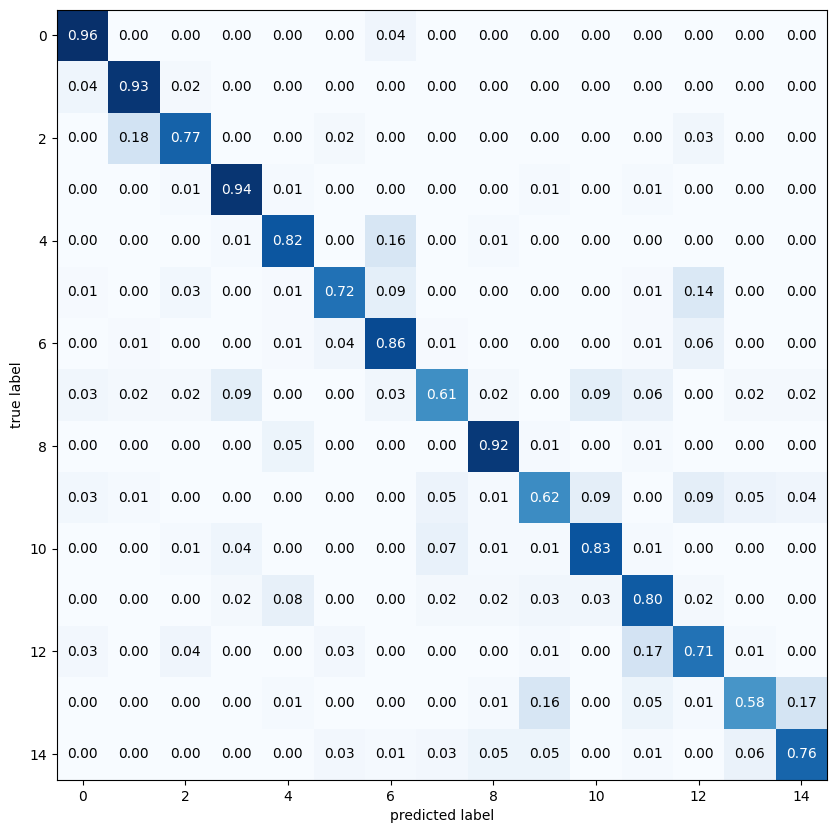

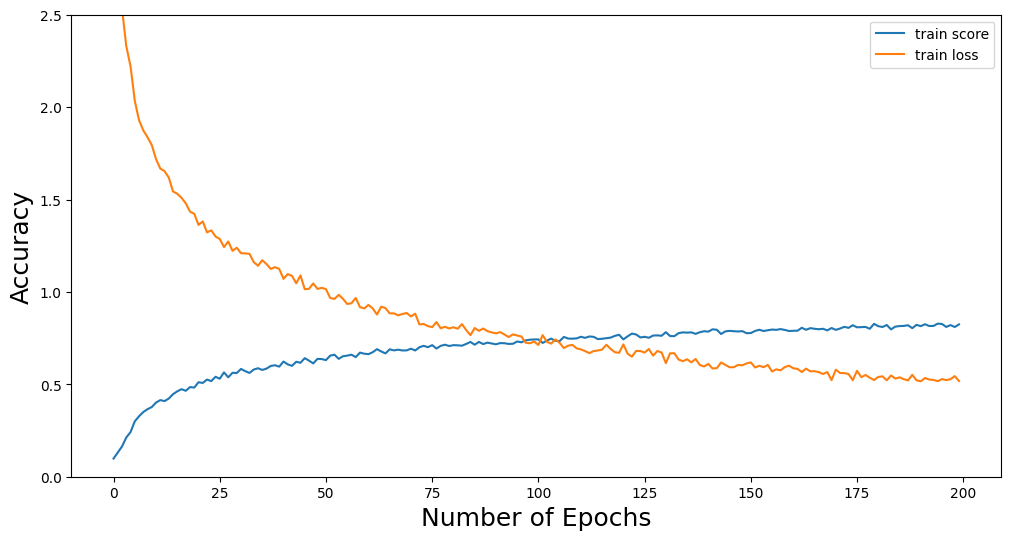

Train Data Shape: (2261, 300, 12)
Test Data Shape: (1128, 300, 12)


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_161 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_23    │ (None, 31, 64)    │          0 │ conv1d_161[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_253         │ (None, 31, 64)    │          0 │ max_pooling1d_23… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_253[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_23        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_23[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_23[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_255         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_255[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_138 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_23[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_162 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_138[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_256         │ (None, 31, 256)   │          0 │ conv1d_162[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_163 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_256[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_163[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_139 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_138[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_139[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_139[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_258         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_258[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.0886 - loss: 3.1274
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.1420 - loss: 2.5978
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.2207 - loss: 2.3735
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.2746 - loss: 2.1705
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.3296 - loss: 2.0110
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.3680 - loss: 1.8872
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.4189 - loss: 1.7826
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.4311 - loss: 1.6680
Epoch 9/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.4137 - loss: 1.6995
Epoch 10/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.4600 - loss: 1.5787
Epoch 11/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.4593 - loss: 1.5339
Epoch 12/200
36/36 ━━━━━━━━━━━━━━━━━━━━

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.8771 - loss: 0.3632
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7839 - loss: 0.8994
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
>#24: 
  train accuracy: 0.85891
  train loss    : 0.41346
  test accuracy: 0.73227
  test loss    : 1.30850

Accuracy: 0.73227 (+/-0.00000)
Loss: 1.30850 (+/-0.00000)


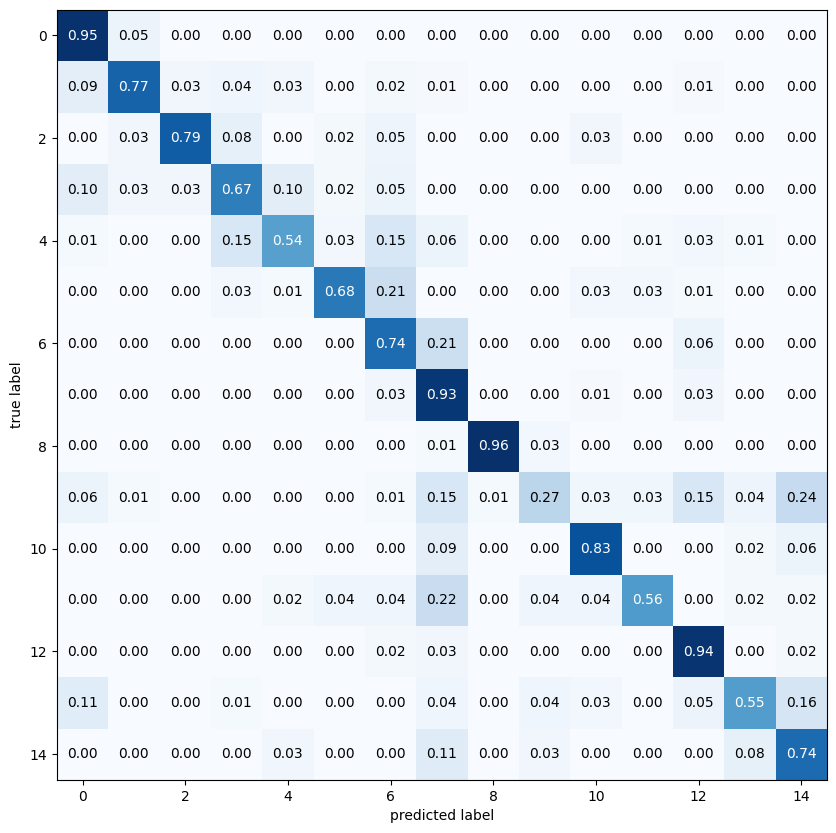

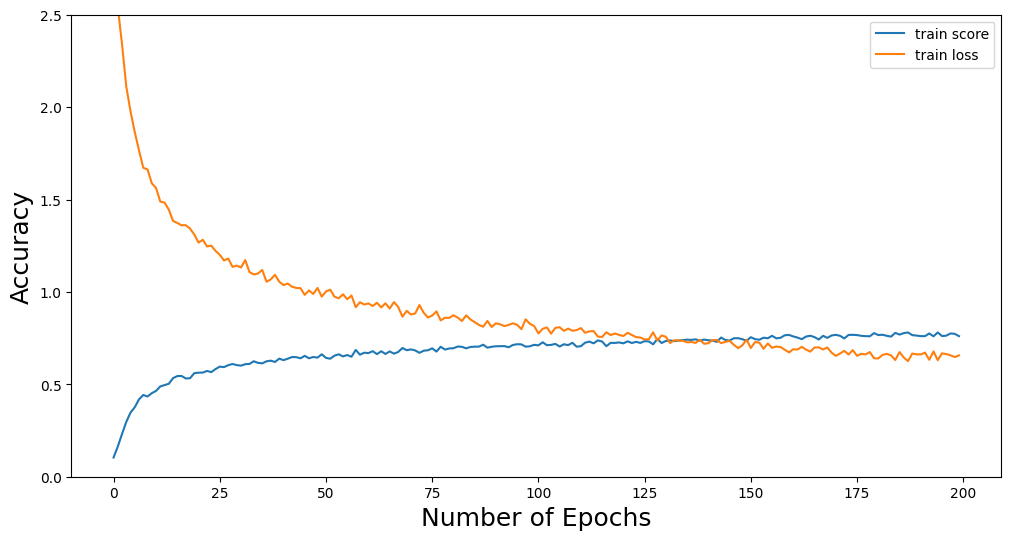

Train Data Shape: (1675, 300, 12)
Test Data Shape: (817, 300, 12)


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_168 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_24    │ (None, 31, 64)    │          0 │ conv1d_168[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_264         │ (None, 31, 64)    │          0 │ max_pooling1d_24… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_264[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_24        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_24[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_24[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_266         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_266[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_144 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_24[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_169 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_144[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_267         │ (None, 31, 256)   │          0 │ conv1d_169[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_170 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_267[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_170[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_145 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_144[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_145[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_145[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_269         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_269[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.0813 - loss: 3.2260
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.1281 - loss: 2.6739
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.1415 - loss: 2.5721
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.2039 - loss: 2.4506
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.2431 - loss: 2.3418
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.2756 - loss: 2.2090
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.3276 - loss: 2.0992
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.3203 - loss: 2.0623
Epoch 9/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.3949 - loss: 1.8612
Epoch 10/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.3768 - loss: 1.8856
Epoch 11/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.4176 - loss: 1.7918
Epoch 12/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9449 - loss: 0.1519
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9137 - loss: 0.3455
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
>#25: 
  train accuracy: 0.92299
  train loss    : 0.22199
  test accuracy: 0.87393
  test loss    : 0.49132

Accuracy: 0.87393 (+/-0.00000)
Loss: 0.49132 (+/-0.00000)


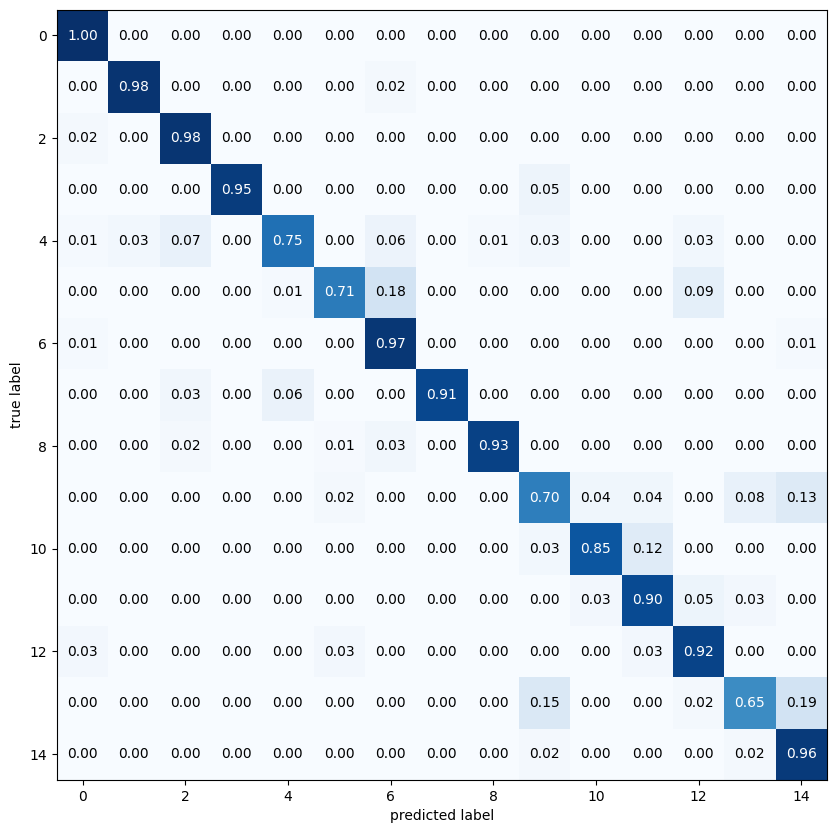

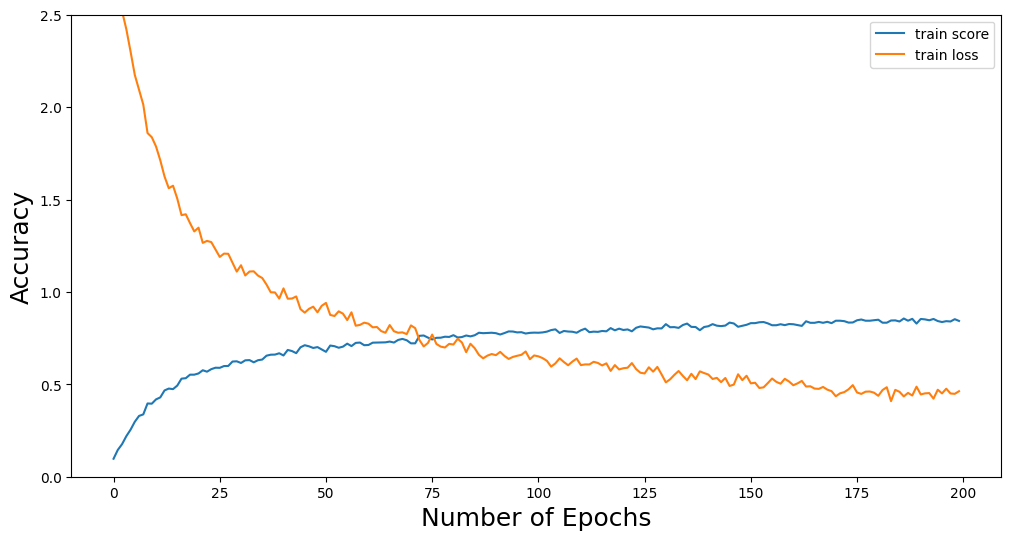

Train Data Shape: (2629, 300, 12)
Test Data Shape: (1329, 300, 12)


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_175 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_25    │ (None, 31, 64)    │          0 │ conv1d_175[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_275         │ (None, 31, 64)    │          0 │ max_pooling1d_25… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_275[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_25        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_25[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_25[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_277         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_277[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_150 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_25[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_176 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_150[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_278         │ (None, 31, 256)   │          0 │ conv1d_176[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_177 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_278[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_177[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_151 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_150[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_151[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_151[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_280         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_280[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.0789 - loss: 3.1131
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.1010 - loss: 2.7248
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.1238 - loss: 2.6487
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.1475 - loss: 2.5626
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.1895 - loss: 2.4372
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.2398 - loss: 2.2960
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.2661 - loss: 2.2174
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.2837 - loss: 2.1314
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.3288 - loss: 2.0360
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.3293 - loss: 1.9744
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.3628 - loss: 1.8787
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9071 - loss: 0.2849
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8349 - loss: 0.6921
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step
>#26: 
  train accuracy: 0.89768
  train loss    : 0.30500
  test accuracy: 0.78932
  test loss    : 0.96360

Accuracy: 0.78932 (+/-0.00000)
Loss: 0.96360 (+/-0.00000)


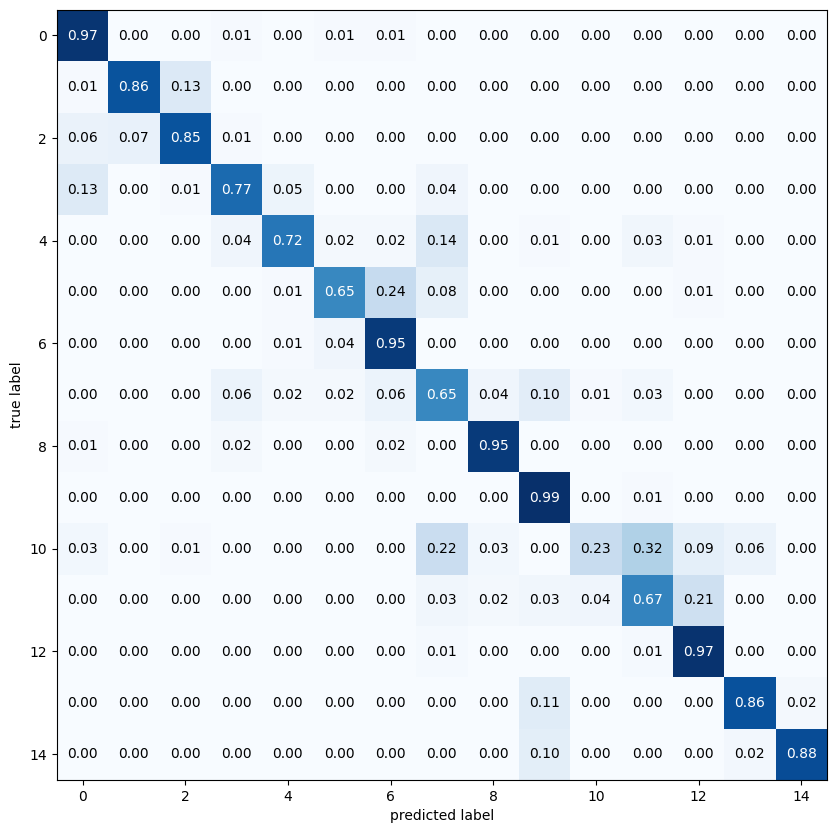

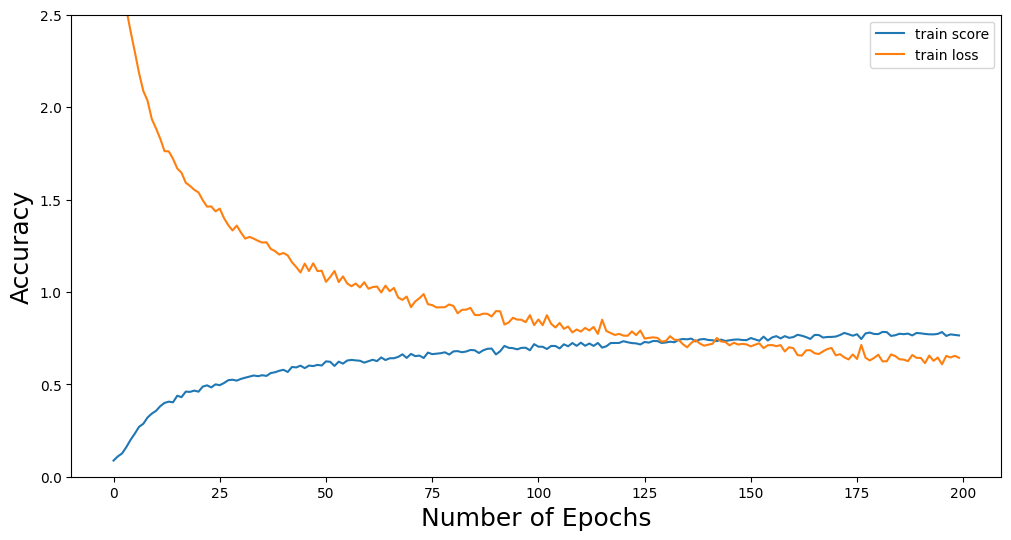

Train Data Shape: (1857, 300, 12)
Test Data Shape: (929, 300, 12)


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_182 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_26    │ (None, 31, 64)    │          0 │ conv1d_182[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_286         │ (None, 31, 64)    │          0 │ max_pooling1d_26… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_286[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_26        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_26[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_288         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_288[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_156 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_183 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_156[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_289         │ (None, 31, 256)   │          0 │ conv1d_183[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_184 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_289[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_184[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_157 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_156[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_157[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_157[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_291         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_291[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step - accuracy: 0.0712 - loss: 3.1510
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.1253 - loss: 2.7271
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.1115 - loss: 2.6573
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.1137 - loss: 2.6696
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.1560 - loss: 2.5635
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.1463 - loss: 2.5488
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.1760 - loss: 2.4350
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.2131 - loss: 2.3720
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.2206 - loss: 2.2955
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.2582 - loss: 2.1876
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.2869 - loss: 2.1373
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9494 - loss: 0.1410
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8469 - loss: 0.7286
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
>#27: 
  train accuracy: 0.93215
  train loss    : 0.18735
  test accuracy: 0.82777
  test loss    : 0.77885

Accuracy: 0.82777 (+/-0.00000)
Loss: 0.77885 (+/-0.00000)


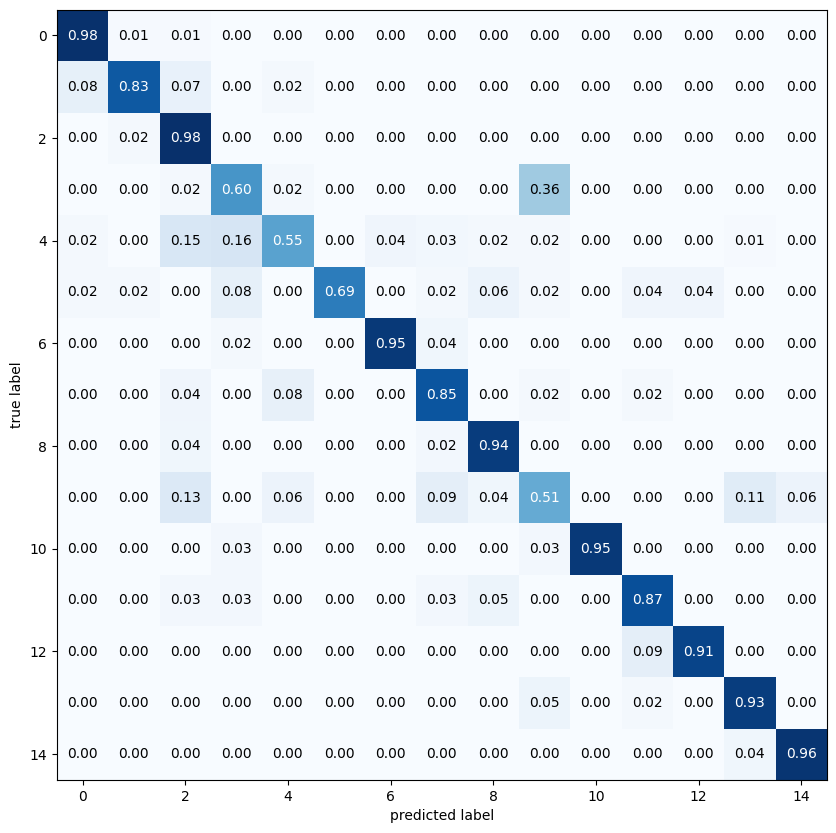

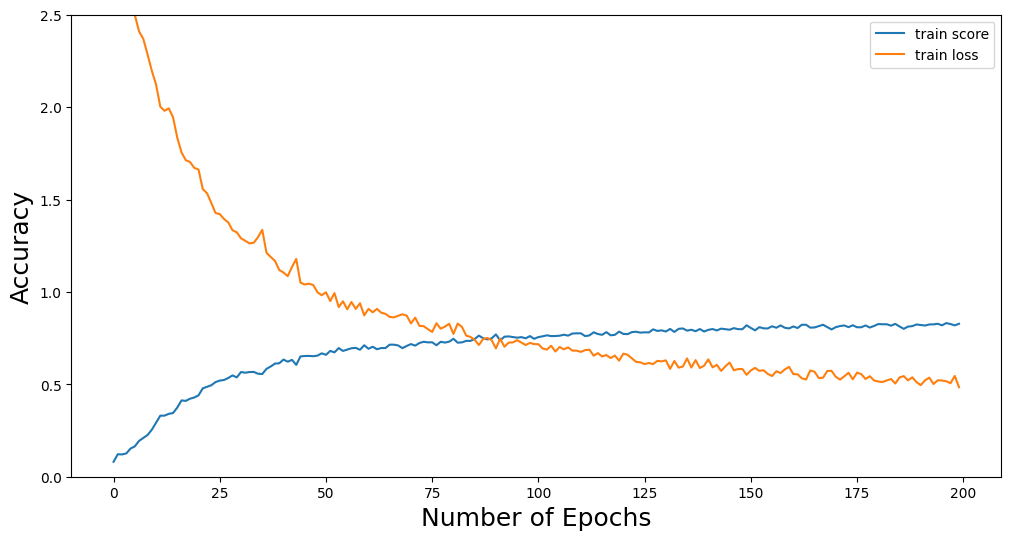

Train Data Shape: (2722, 300, 12)
Test Data Shape: (1280, 300, 12)


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_189 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_27    │ (None, 31, 64)    │          0 │ conv1d_189[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_297         │ (None, 31, 64)    │          0 │ max_pooling1d_27… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_297[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_27        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_27[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_27[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_299         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_299[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_162 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_27[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_190 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_162[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_300         │ (None, 31, 256)   │          0 │ conv1d_190[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_191 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_300[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_191[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_163 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_162[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_163[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_163[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_302         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_302[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.0771 - loss: 3.0461
Epoch 2/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.1128 - loss: 2.7121
Epoch 3/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.1523 - loss: 2.6026
Epoch 4/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.1811 - loss: 2.4788
Epoch 5/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.2668 - loss: 2.2625
Epoch 6/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.3102 - loss: 2.1146
Epoch 7/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.3428 - loss: 1.9683
Epoch 8/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.3609 - loss: 1.9075
Epoch 9/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.3771 - loss: 1.8463
Epoch 10/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.3834 - loss: 1.8208
Epoch 11/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.3973 - loss: 1.7587
Epoch 12/200
43/43 ━━━━━━━━━━━━━━━━━━━

43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.8739 - loss: 0.3843
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.6922 - loss: 1.3345
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step
>#28: 
  train accuracy: 0.85158
  train loss    : 0.45629
  test accuracy: 0.71406
  test loss    : 1.18822

Accuracy: 0.71406 (+/-0.00000)
Loss: 1.18822 (+/-0.00000)


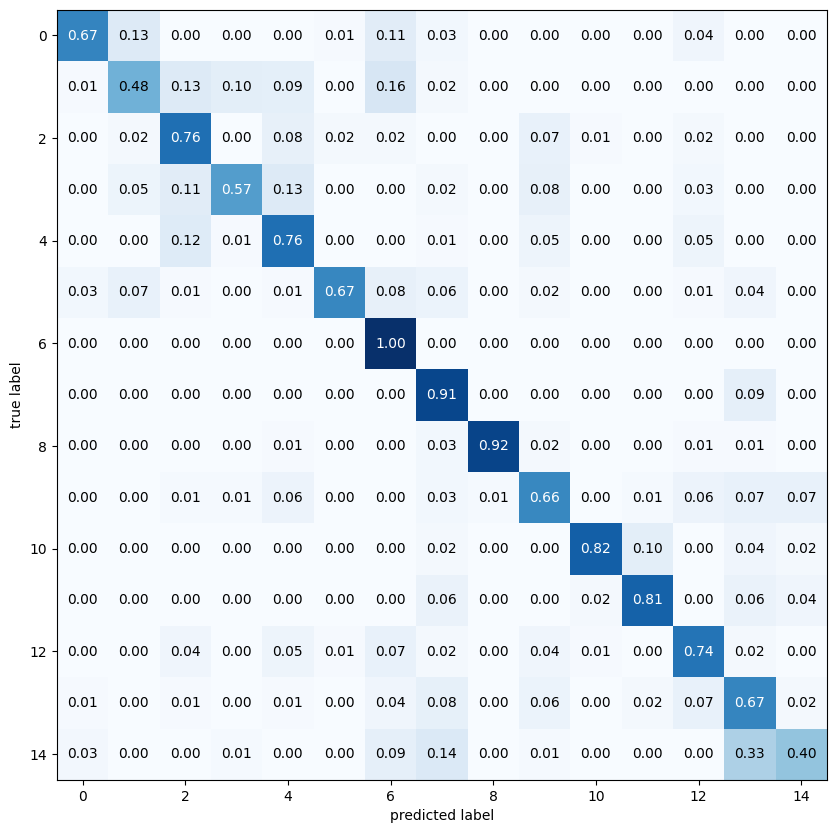

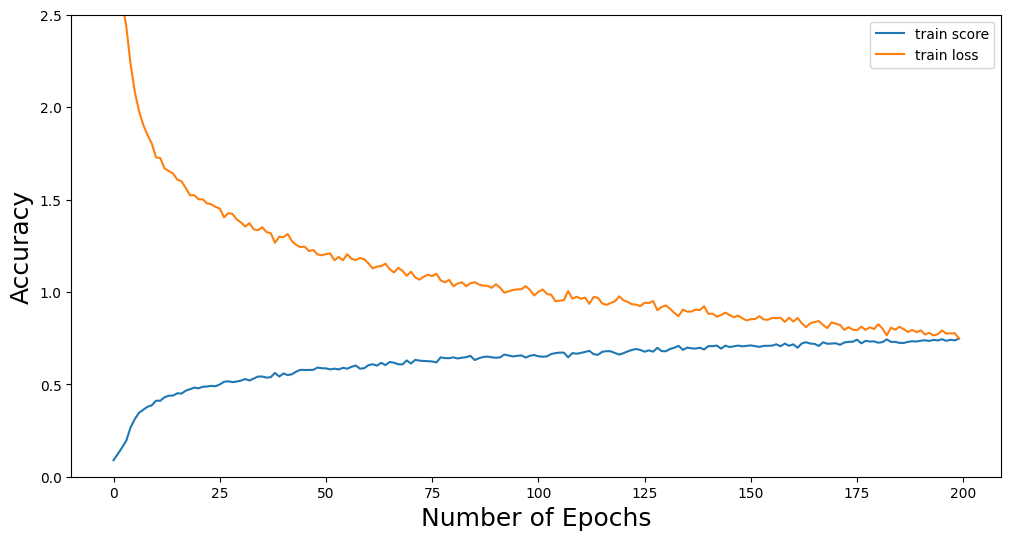

Train Data Shape: (1756, 300, 12)
Test Data Shape: (914, 300, 12)


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_196 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_28    │ (None, 31, 64)    │          0 │ conv1d_196[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_308         │ (None, 31, 64)    │          0 │ max_pooling1d_28… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_308[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_28        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_28[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_28[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_310         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_310[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_168 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_28[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_197 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_168[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_311         │ (None, 31, 256)   │          0 │ conv1d_197[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_198 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_311[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_198[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_169 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_168[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_169[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_169[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_313         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_313[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 304ms/step - accuracy: 0.1005 - loss: 3.1489
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 402ms/step - accuracy: 0.1228 - loss: 2.6450
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.1893 - loss: 2.4924
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.1865 - loss: 2.4088
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step - accuracy: 0.2375 - loss: 2.3474
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.2688 - loss: 2.2238
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.3469 - loss: 2.0677
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.3660 - loss: 1.9545
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.4270 - loss: 1.8682
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.4270 - loss: 1.7351
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.4290 - loss: 1.7297
Epoch 12/200
28/28 ━━━━━━━━━━━━━━━━━━━

28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9542 - loss: 0.1108
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.7687 - loss: 0.9618
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step
>#29: 
  train accuracy: 0.95046
  train loss    : 0.12547
  test accuracy: 0.79759
  test loss    : 1.00607

Accuracy: 0.79759 (+/-0.00000)
Loss: 1.00607 (+/-0.00000)


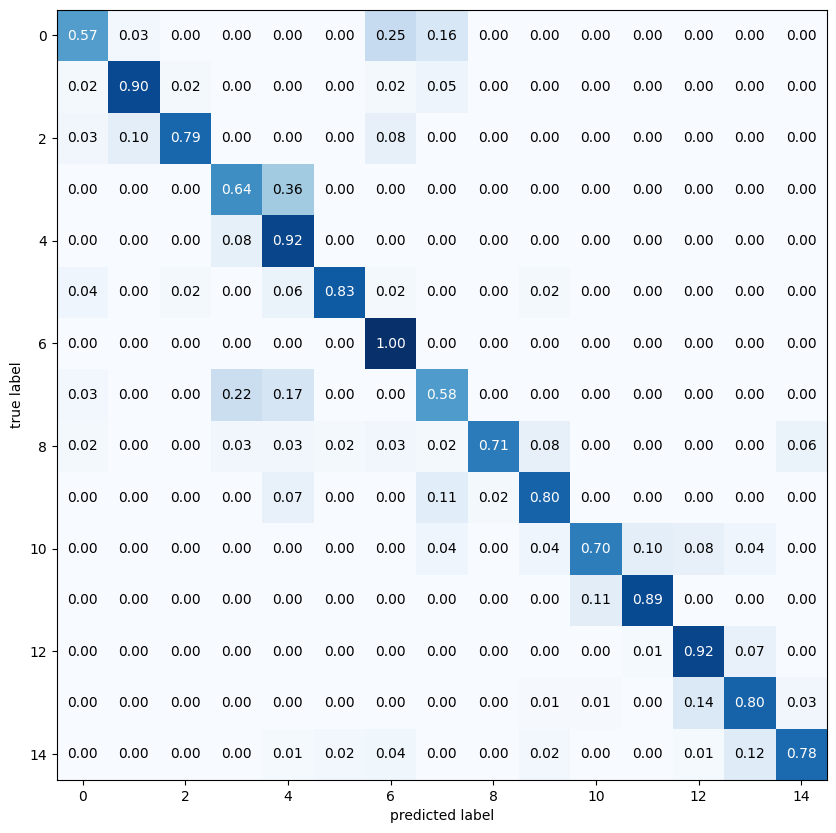

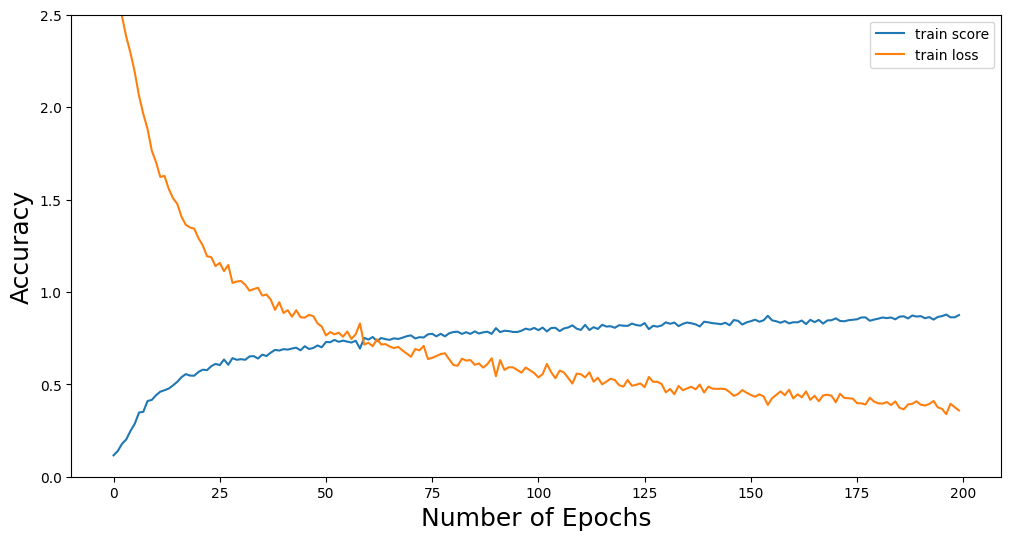

Train Data Shape: (2467, 300, 12)
Test Data Shape: (1273, 300, 12)


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_203 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_29    │ (None, 31, 64)    │          0 │ conv1d_203[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_319         │ (None, 31, 64)    │          0 │ max_pooling1d_29… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_319[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_29        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_29[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_321         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_321[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_174 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_204 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_174[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_322         │ (None, 31, 256)   │          0 │ conv1d_204[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_205 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_322[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_205[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_175 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_174[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_175[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_175[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_324         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_324[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 231ms/step - accuracy: 0.0727 - loss: 3.0737
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.0981 - loss: 2.7274
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 315ms/step - accuracy: 0.1093 - loss: 2.6280
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.1384 - loss: 2.5421
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.1386 - loss: 2.4785
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step - accuracy: 0.1523 - loss: 2.4314
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - accuracy: 0.1589 - loss: 2.3907
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 0.1705 - loss: 2.3466
Epoch 9/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.1791 - loss: 2.2782
Epoch 10/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.1725 - loss: 2.3311
Epoch 11/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.2156 - loss: 2.1964
Epoch 12/200
39/39 ━━━━━━━━━━━

39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.8871 - loss: 0.2906
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8156 - loss: 0.6390
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step
>#30: 
  train accuracy: 0.87150
  train loss    : 0.35273
  test accuracy: 0.79026
  test loss    : 0.74871

Accuracy: 0.79026 (+/-0.00000)
Loss: 0.74871 (+/-0.00000)


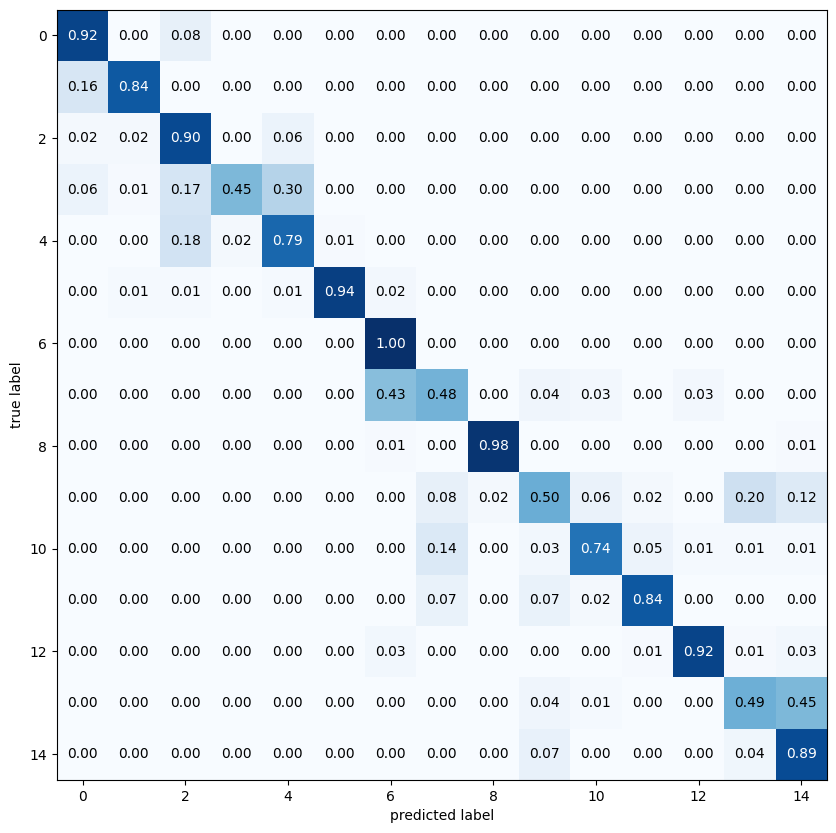

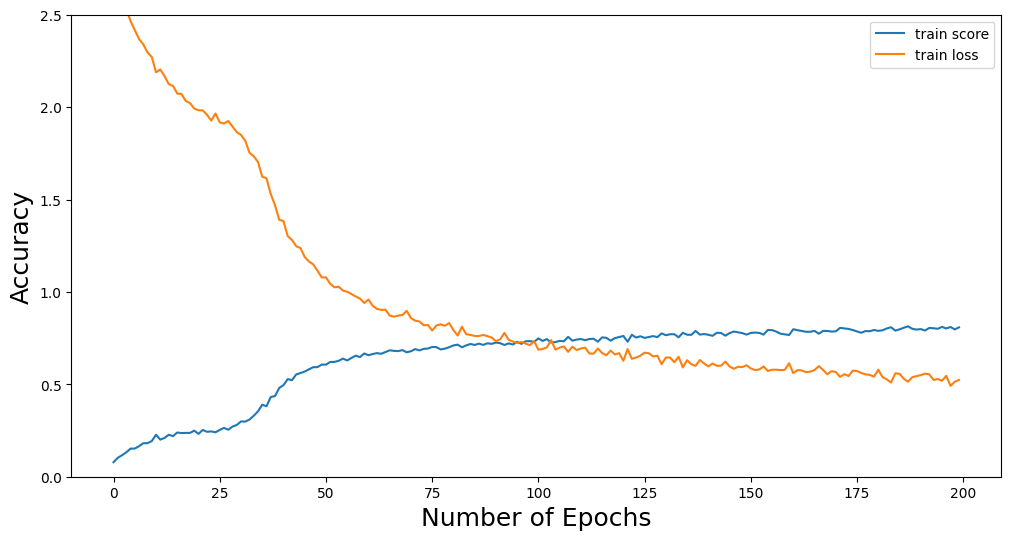

Train Data Shape: (2561, 300, 12)
Test Data Shape: (1282, 300, 12)


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_210 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_30    │ (None, 31, 64)    │          0 │ conv1d_210[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_330         │ (None, 31, 64)    │          0 │ max_pooling1d_30… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_330[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_30        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_30[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_30[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_332         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_332[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_180 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_30[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_211 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_180[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_333         │ (None, 31, 256)   │          0 │ conv1d_211[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_212 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_333[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_212[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_181 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_180[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_181[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_181[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_335         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_335[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 196ms/step - accuracy: 0.0767 - loss: 3.0591
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.0966 - loss: 2.7418
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.0978 - loss: 2.7083
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 0.1310 - loss: 2.6275
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.1334 - loss: 2.5994
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.1812 - loss: 2.4880
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - accuracy: 0.2271 - loss: 2.4161
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.2120 - loss: 2.3634
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.2735 - loss: 2.2210
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.2523 - loss: 2.2328
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.2856 - loss: 2.1537
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8556 - loss: 0.3936
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7874 - loss: 0.7653
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
>#31: 
  train accuracy: 0.80164
  train loss    : 0.55162
  test accuracy: 0.73011
  test loss    : 0.97050

Accuracy: 0.73011 (+/-0.00000)
Loss: 0.97050 (+/-0.00000)


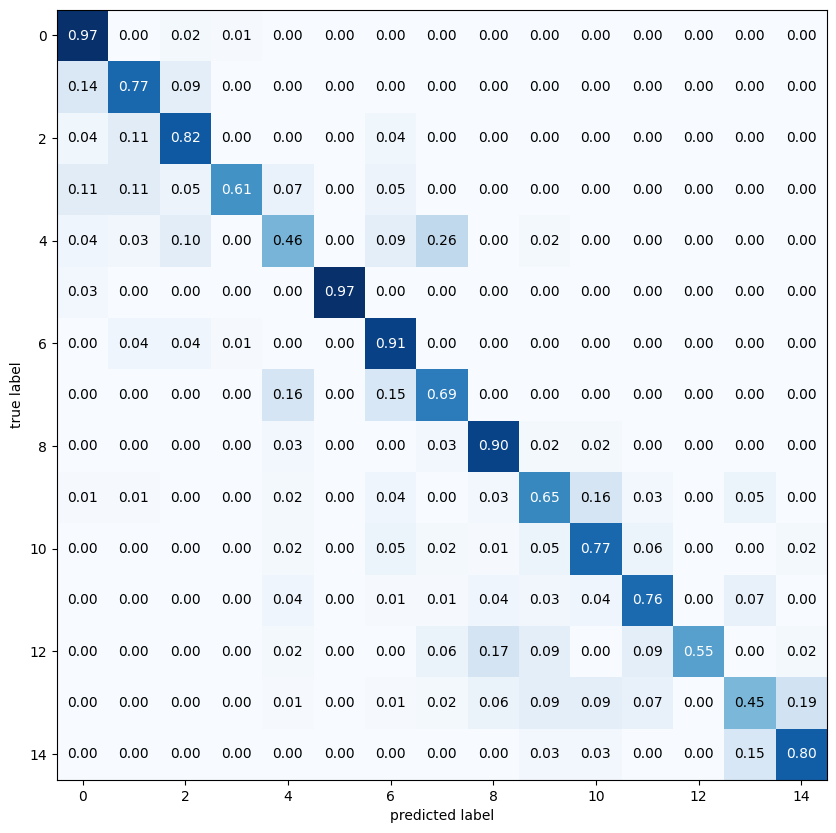

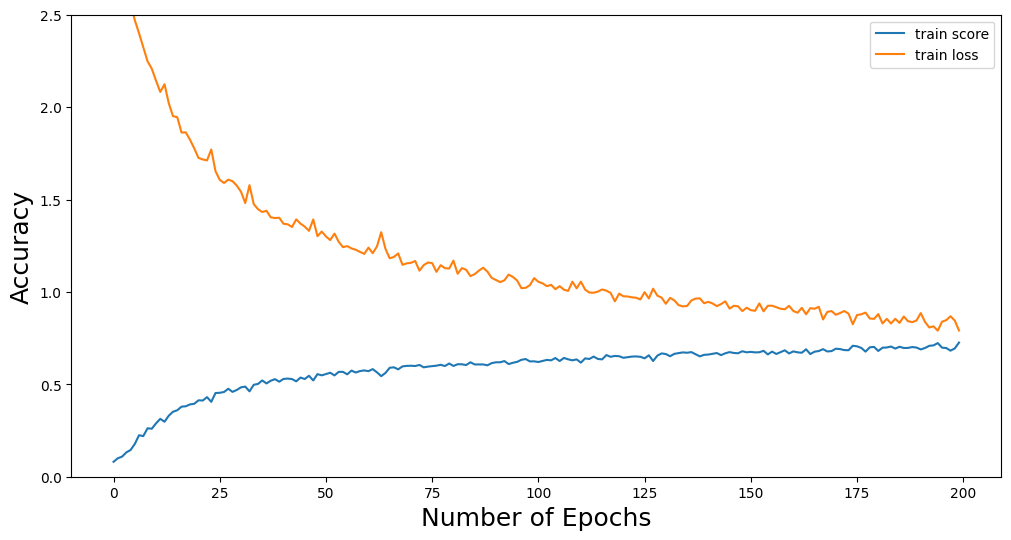

Train Data Shape: (2040, 300, 12)
Test Data Shape: (973, 300, 12)


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_217 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_31[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_31    │ (None, 31, 64)    │          0 │ conv1d_217[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_341         │ (None, 31, 64)    │          0 │ max_pooling1d_31… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_341[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_31        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_31[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_31[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_343         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_343[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_186 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_31[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_218 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_186[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_344         │ (None, 31, 256)   │          0 │ conv1d_218[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_219 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_344[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_219[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_187 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_186[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_187[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_187[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_346         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_346[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 188ms/step - accuracy: 0.0910 - loss: 3.0190
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.1267 - loss: 2.6271
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.1763 - loss: 2.5316
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.2181 - loss: 2.4297
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.2690 - loss: 2.2687
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.3180 - loss: 2.1062
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.3417 - loss: 2.0040
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.3670 - loss: 1.9313
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.4072 - loss: 1.8130
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.4335 - loss: 1.7065
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.4505 - loss: 1.7109
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9280 - loss: 0.2196
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8357 - loss: 0.6657
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
>#32: 
  train accuracy: 0.91618
  train loss    : 0.25350
  test accuracy: 0.82528
  test loss    : 0.70900

Accuracy: 0.82528 (+/-0.00000)
Loss: 0.70900 (+/-0.00000)


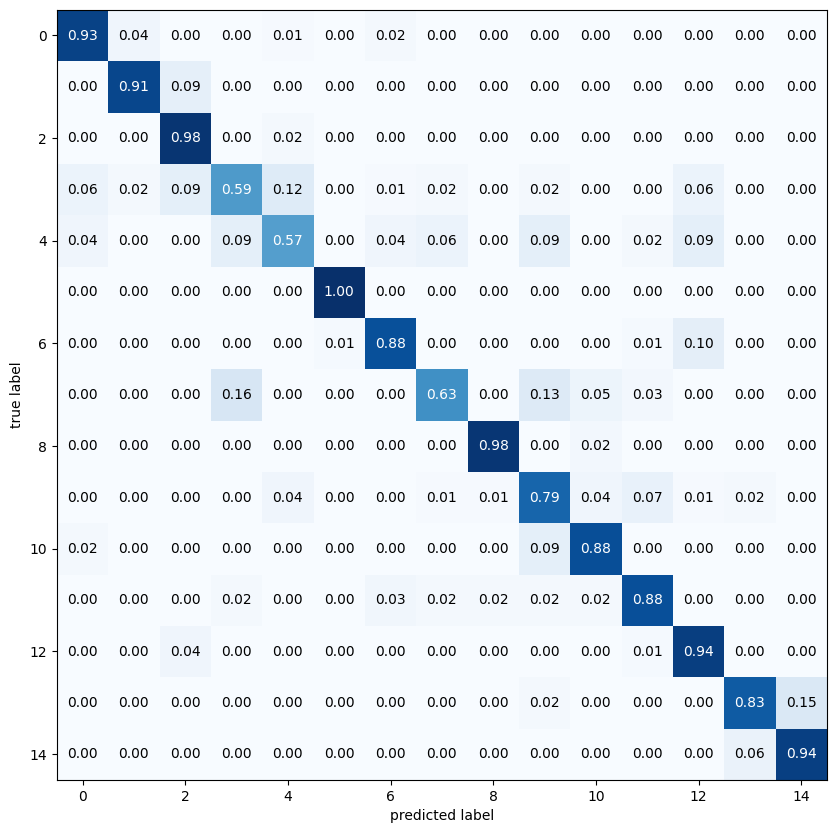

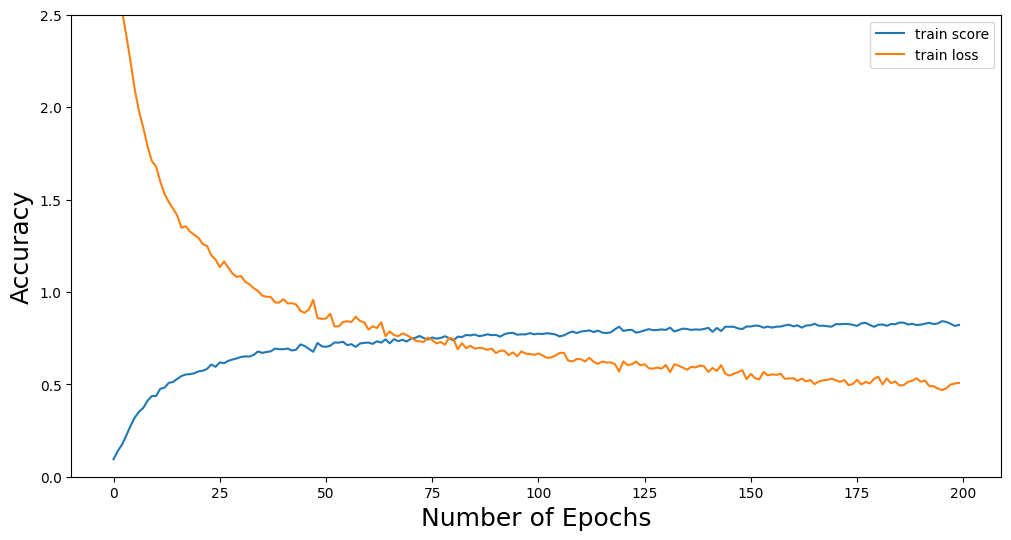

Train Data Shape: (2311, 300, 12)
Test Data Shape: (1101, 300, 12)


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_224 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_32    │ (None, 31, 64)    │          0 │ conv1d_224[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_352         │ (None, 31, 64)    │          0 │ max_pooling1d_32… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_352[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_32        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_32[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_354         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_354[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_192 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_225 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_192[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_355         │ (None, 31, 256)   │          0 │ conv1d_225[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_226 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_355[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_226[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_193 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_192[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_193[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_193[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_357         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_357[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 243ms/step - accuracy: 0.0940 - loss: 3.0435
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.1342 - loss: 2.6613
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.1606 - loss: 2.5274
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.2382 - loss: 2.3336
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.2910 - loss: 2.1597
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.3581 - loss: 1.9680
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.3870 - loss: 1.8319
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.4075 - loss: 1.7404
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - accuracy: 0.4915 - loss: 1.5416
Epoch 10/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.4934 - loss: 1.4901
Epoch 11/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.5095 - loss: 1.4109
Epoch 12/200
37/37 ━━━━━━━━━━━━━━━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9659 - loss: 0.1125
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9449 - loss: 0.2027
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step
>#33: 
  train accuracy: 0.94634
  train loss    : 0.16631
  test accuracy: 0.91099
  test loss    : 0.32239

Accuracy: 0.91099 (+/-0.00000)
Loss: 0.32239 (+/-0.00000)


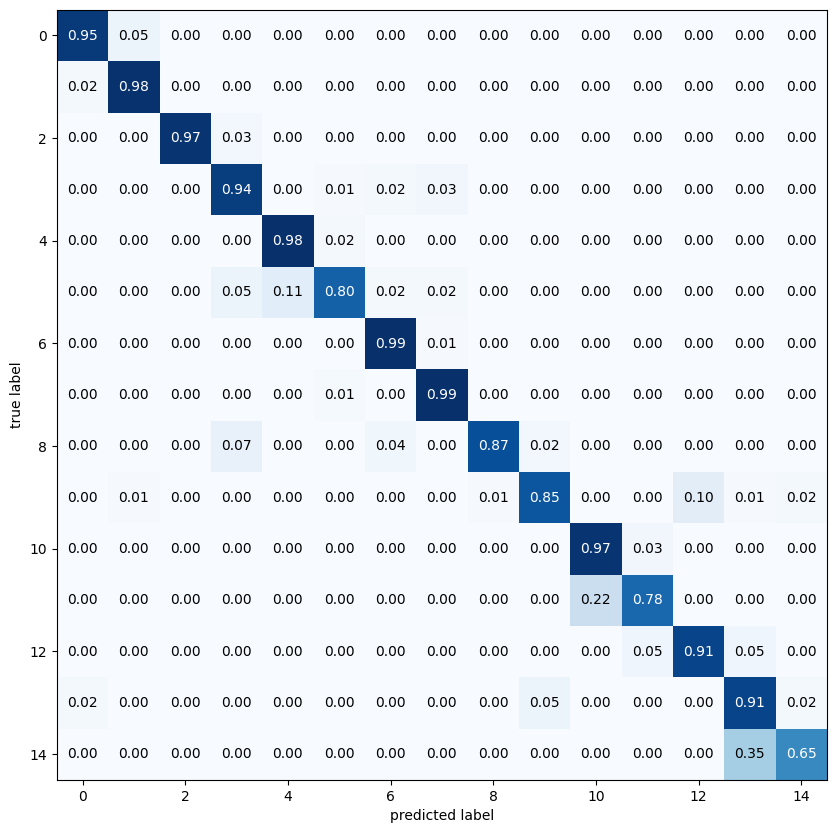

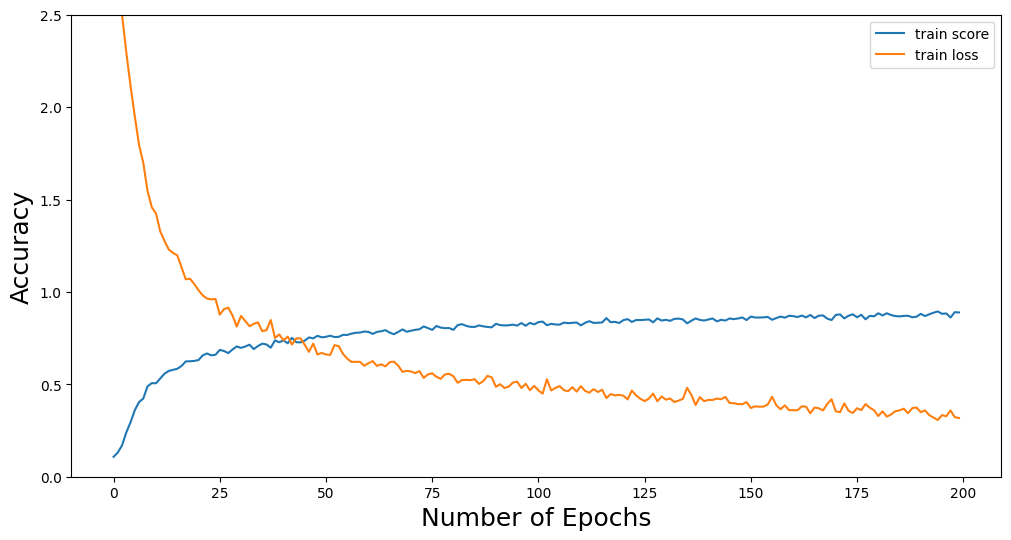

Train Data Shape: (2233, 300, 12)
Test Data Shape: (1124, 300, 12)


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_231 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_33    │ (None, 31, 64)    │          0 │ conv1d_231[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_363         │ (None, 31, 64)    │          0 │ max_pooling1d_33… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_363[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_33        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_33[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_365         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_365[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_198 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_232 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_198[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_366         │ (None, 31, 256)   │          0 │ conv1d_232[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_233 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_366[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_233[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_199 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_198[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_199[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_199[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_368         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_368[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.0875 - loss: 3.1603
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - accuracy: 0.1324 - loss: 2.6482
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.1556 - loss: 2.5615
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.2292 - loss: 2.3903
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.2715 - loss: 2.1811
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.3079 - loss: 2.0289
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.3455 - loss: 1.8612
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - accuracy: 0.3936 - loss: 1.7910
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.4027 - loss: 1.6961
Epoch 10/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.4632 - loss: 1.5440
Epoch 11/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.4682 - loss: 1.5169
Epoch 12/200
35/35 ━━━━━━━━━━━━━━━━━━

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9788 - loss: 0.0701
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.8857 - loss: 0.5394
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step
>#34: 
  train accuracy: 0.97223
  train loss    : 0.08738
  test accuracy: 0.84964
  test loss    : 0.77209

Accuracy: 0.84964 (+/-0.00000)
Loss: 0.77209 (+/-0.00000)


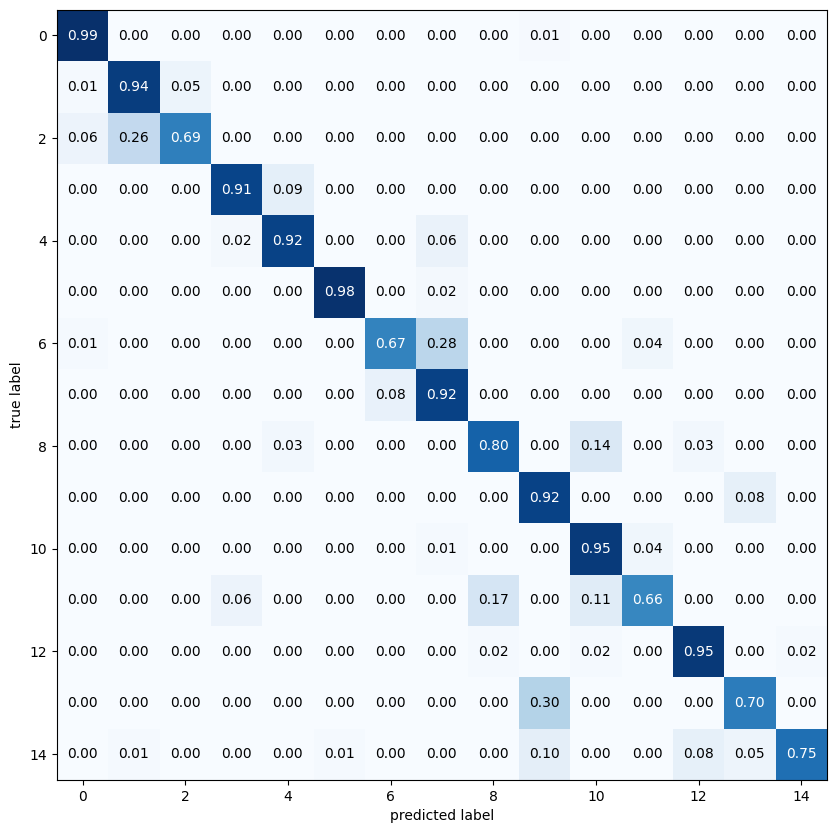

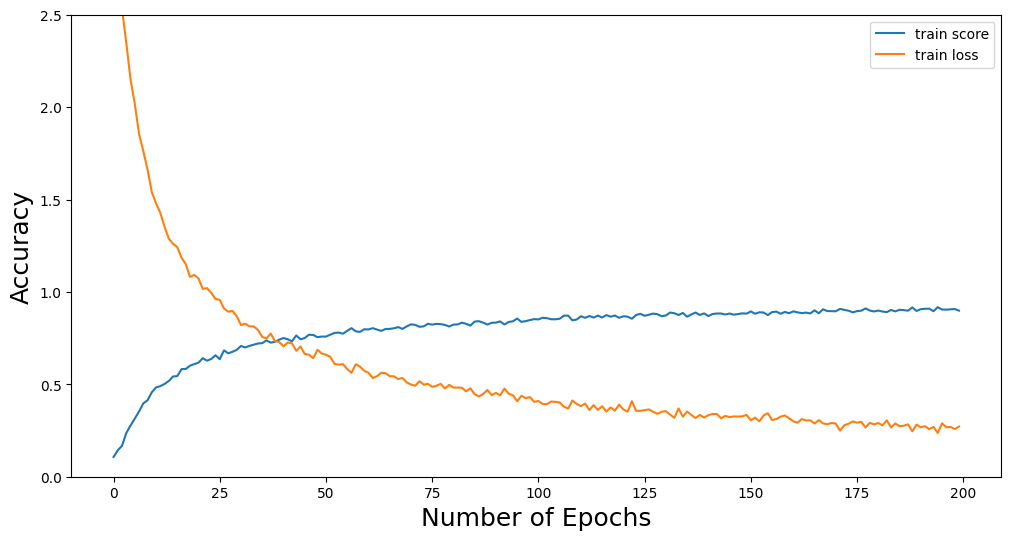

Train Data Shape: (2785, 300, 12)
Test Data Shape: (1392, 300, 12)


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_238 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_34    │ (None, 31, 64)    │          0 │ conv1d_238[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_374         │ (None, 31, 64)    │          0 │ max_pooling1d_34… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_374[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_34        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_34[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_34[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_376         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_376[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_204 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_34[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_239 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_204[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_377         │ (None, 31, 256)   │          0 │ conv1d_239[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_240 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_377[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_240[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_205 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_204[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_205[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_205[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_379         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_379[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step - accuracy: 0.0770 - loss: 3.0352
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.1038 - loss: 2.7240
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.1167 - loss: 2.6487
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.1368 - loss: 2.6009
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.1858 - loss: 2.4943
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.2225 - loss: 2.3898
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.2611 - loss: 2.2811
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.2889 - loss: 2.1533
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.3055 - loss: 2.0750
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.3285 - loss: 1.9939
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.3383 - loss: 1.9545
Epoch 12/200
44/44 ━━━━━━━━━━━

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9322 - loss: 0.2288
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.8263 - loss: 0.6906
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
>#35: 
  train accuracy: 0.90952
  train loss    : 0.27692
  test accuracy: 0.77945
  test loss    : 0.91775

Accuracy: 0.77945 (+/-0.00000)
Loss: 0.91775 (+/-0.00000)


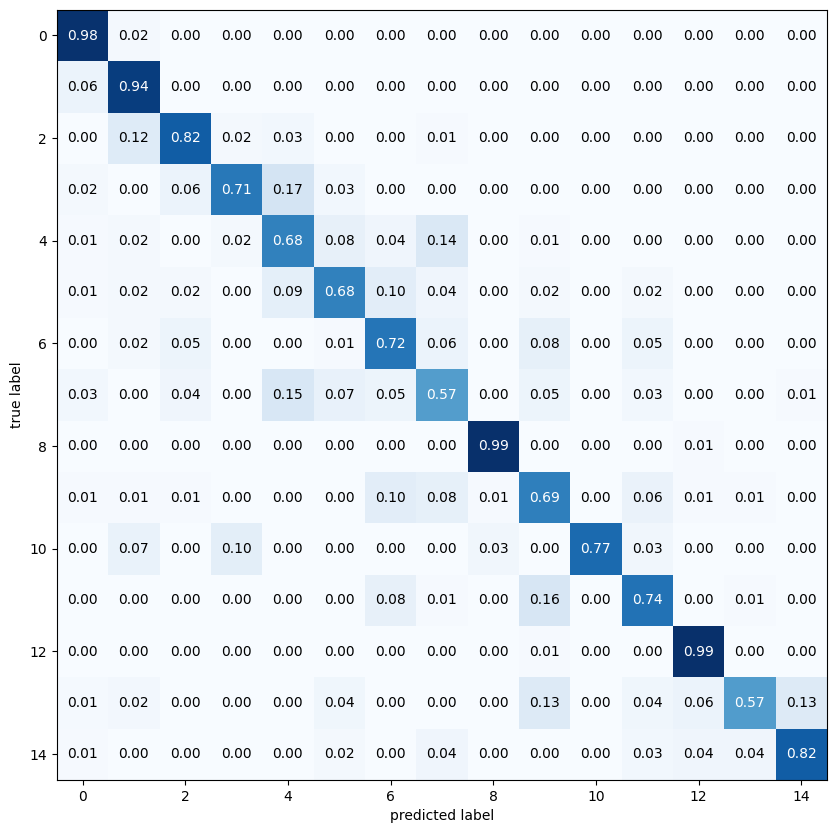

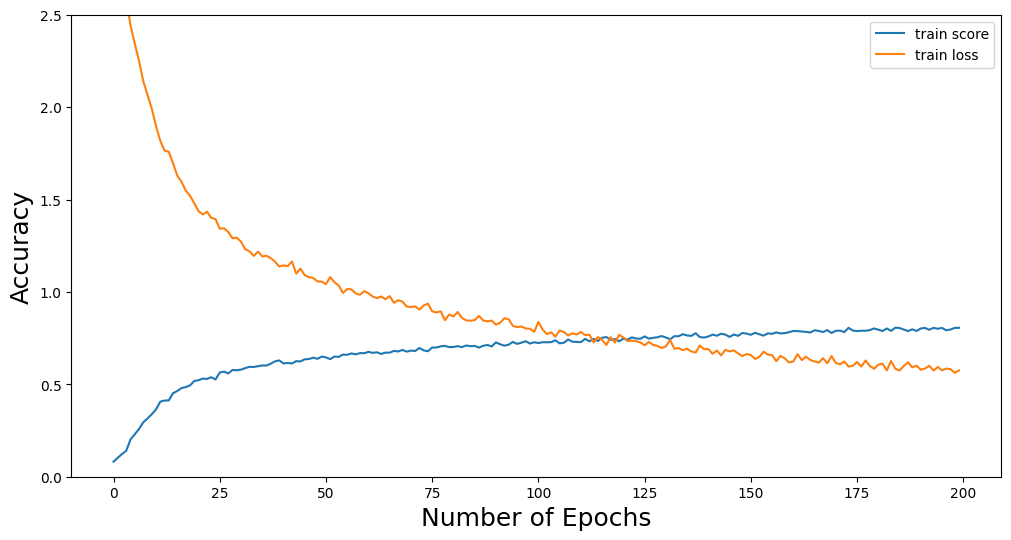

Train Data Shape: (2005, 300, 12)
Test Data Shape: (992, 300, 12)


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_245 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_35    │ (None, 31, 64)    │          0 │ conv1d_245[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_385         │ (None, 31, 64)    │          0 │ max_pooling1d_35… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_385[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_35        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_35[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_35[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_387         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_387[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_210 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_35[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_246 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_210[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_388         │ (None, 31, 256)   │          0 │ conv1d_246[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_247 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_388[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_247[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_211 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_210[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_211[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_211[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_390         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_390[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.0938 - loss: 3.0396
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.1250 - loss: 2.6587
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.1439 - loss: 2.6022
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.1849 - loss: 2.5228
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.1862 - loss: 2.4837
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.1986 - loss: 2.4168
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.2156 - loss: 2.3713
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.2632 - loss: 2.2361
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.2828 - loss: 2.1140
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.3258 - loss: 1.9721
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.3688 - loss: 1.8434
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9631 - loss: 0.1089
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8091 - loss: 0.9686
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
>#36: 
  train accuracy: 0.94663
  train loss    : 0.14931
  test accuracy: 0.78528
  test loss    : 1.02321

Accuracy: 0.78528 (+/-0.00000)
Loss: 1.02321 (+/-0.00000)


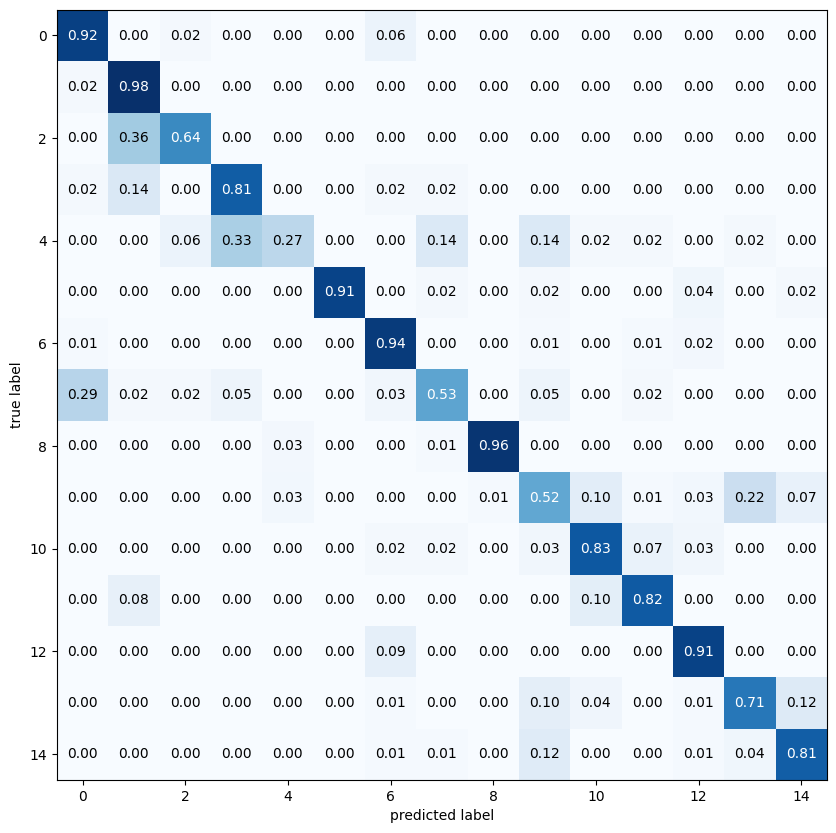

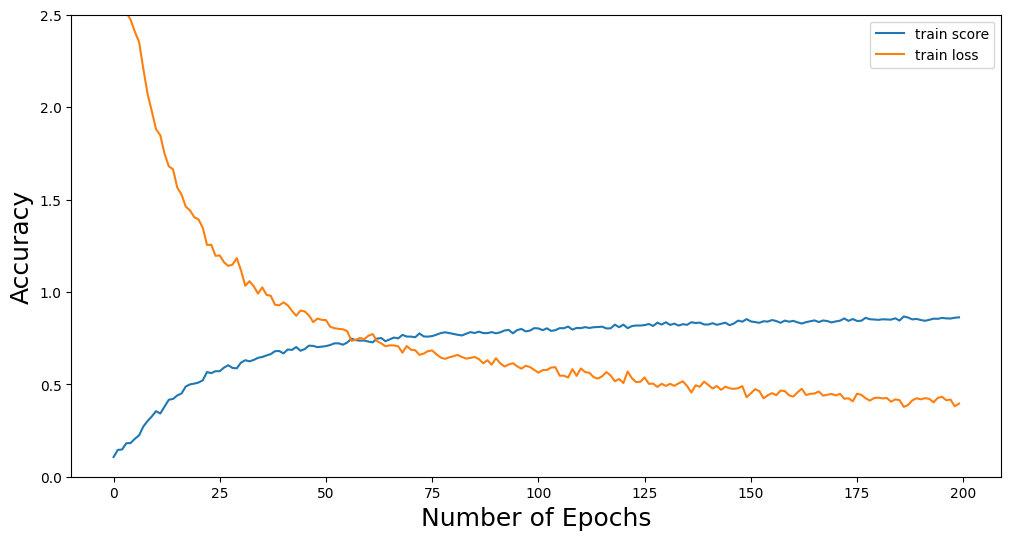

Train Data Shape: (2023, 300, 12)
Test Data Shape: (1011, 300, 12)


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_252 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_36    │ (None, 31, 64)    │          0 │ conv1d_252[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_396         │ (None, 31, 64)    │          0 │ max_pooling1d_36… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_396[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_36        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_36[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_398         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_398[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_216 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_253 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_216[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_399         │ (None, 31, 256)   │          0 │ conv1d_253[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_254 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_399[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_254[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_217 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_216[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_217[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_217[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_401         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_401[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.0786 - loss: 3.0550
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.0897 - loss: 2.7135
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.1441 - loss: 2.6004
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.1706 - loss: 2.4654
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.1684 - loss: 2.4283
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.2076 - loss: 2.3156
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.2232 - loss: 2.2777
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.2661 - loss: 2.1914
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step - accuracy: 0.3118 - loss: 2.0273
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.3267 - loss: 1.9279
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.3642 - loss: 1.8464
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.9679 - loss: 0.0905
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.9128 - loss: 0.3513
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step
>#37: 
  train accuracy: 0.94958
  train loss    : 0.14367
  test accuracy: 0.86251
  test loss    : 0.54658

Accuracy: 0.86251 (+/-0.00000)
Loss: 0.54658 (+/-0.00000)


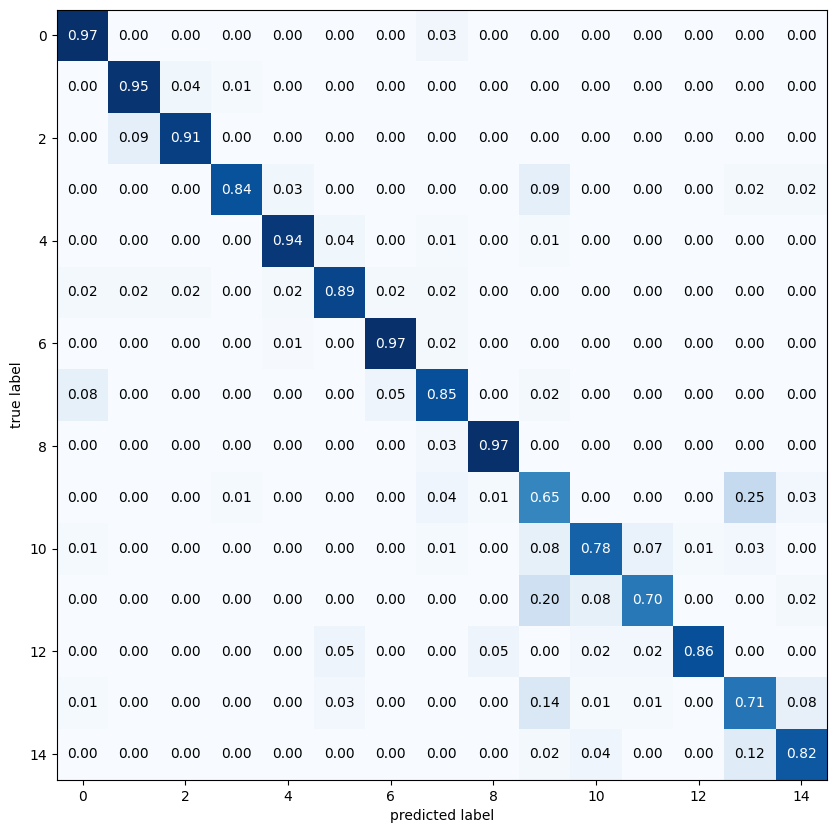

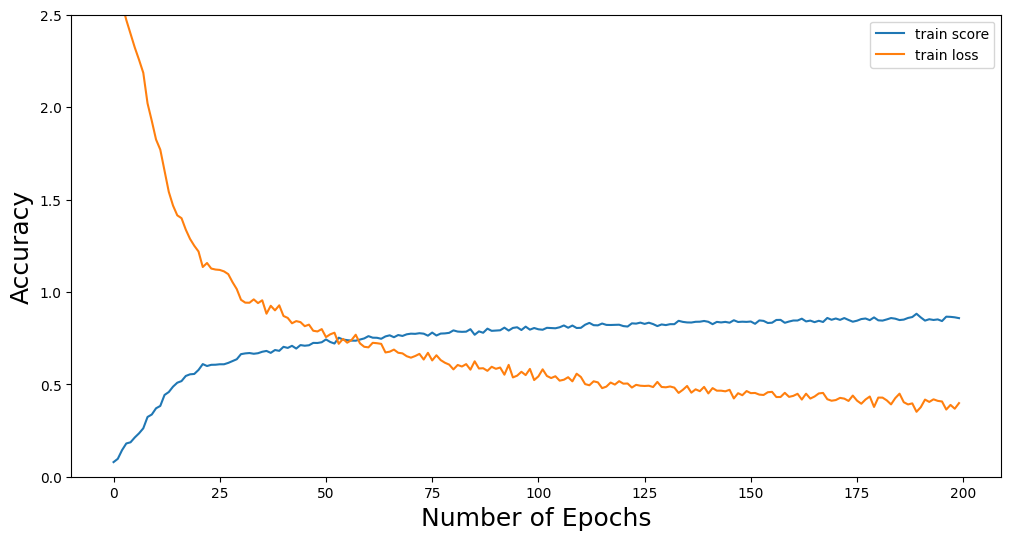

Train Data Shape: (2347, 300, 12)
Test Data Shape: (1173, 300, 12)


Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_259 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_37    │ (None, 31, 64)    │          0 │ conv1d_259[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_407         │ (None, 31, 64)    │          0 │ max_pooling1d_37… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_407[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_37        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_37[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_37[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_409         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_409[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_222 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_37[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_260 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_222[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_410         │ (None, 31, 256)   │          0 │ conv1d_260[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_261 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_410[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_261[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_223 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_222[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_223[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_223[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_412         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_412[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 274ms/step - accuracy: 0.0806 - loss: 3.1223
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.1160 - loss: 2.6540
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - accuracy: 0.1408 - loss: 2.5572
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.1831 - loss: 2.4378
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - accuracy: 0.2431 - loss: 2.2883
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 399ms/step - accuracy: 0.2569 - loss: 2.2328
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 536ms/step - accuracy: 0.2696 - loss: 2.1151
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - accuracy: 0.3033 - loss: 2.0034
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 376ms/step - accuracy: 0.3213 - loss: 1.9513
Epoch 10/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.3521 - loss: 1.9033
Epoch 11/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 332ms/step - accuracy: 0.3488 - loss: 1.8292
Epoch 12/200
37/37 ━━━━━━━━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.8628 - loss: 0.3390
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.7885 - loss: 0.6263
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step
>#38: 
  train accuracy: 0.88794
  train loss    : 0.28693
  test accuracy: 0.81927
  test loss    : 0.61634

Accuracy: 0.81927 (+/-0.00000)
Loss: 0.61634 (+/-0.00000)


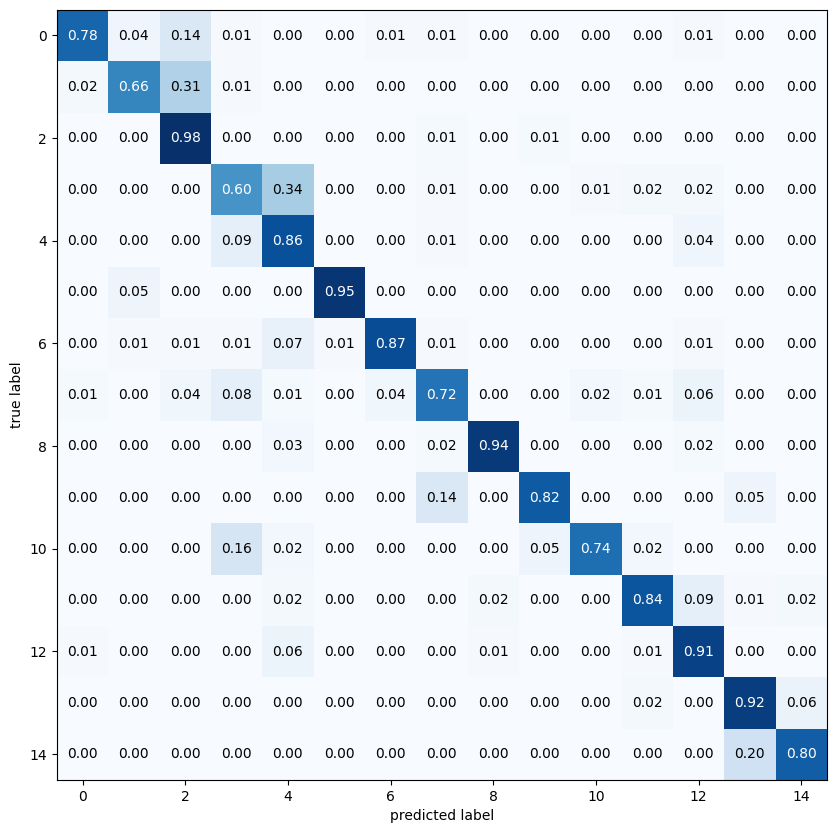

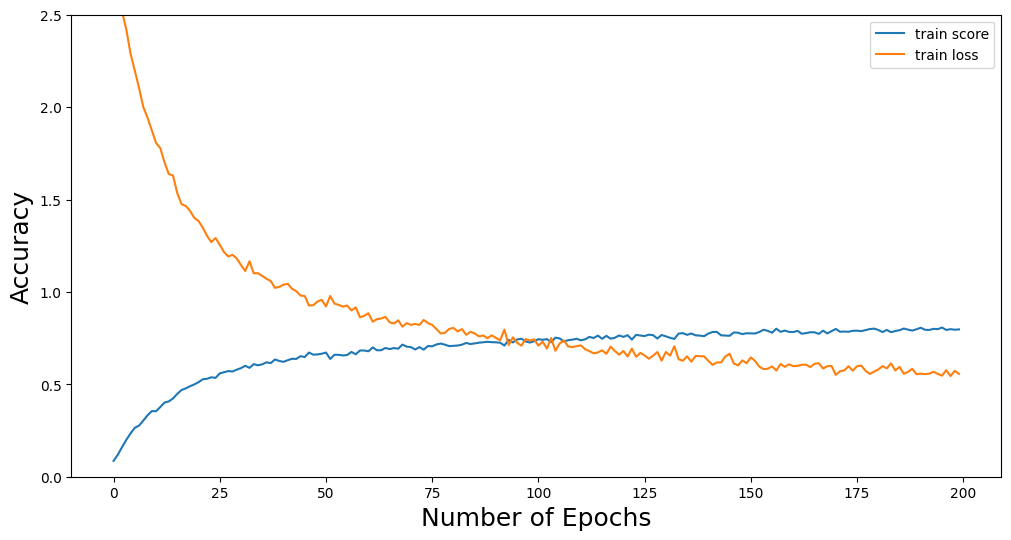

Train Data Shape: (2822, 300, 12)
Test Data Shape: (1401, 300, 12)


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_266 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_38[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_38    │ (None, 31, 64)    │          0 │ conv1d_266[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_418         │ (None, 31, 64)    │          0 │ max_pooling1d_38… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_418[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_38        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_38[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_420         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_420[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_228 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_267 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_228[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_421         │ (None, 31, 256)   │          0 │ conv1d_267[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_268 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_421[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_268[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_229 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_228[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_229[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_229[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_423         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_423[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 285ms/step - accuracy: 0.0807 - loss: 3.0860
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.1158 - loss: 2.6955
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.1434 - loss: 2.5755
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step - accuracy: 0.1806 - loss: 2.4596
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step - accuracy: 0.2122 - loss: 2.3363
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - accuracy: 0.2657 - loss: 2.1824
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 400ms/step - accuracy: 0.3010 - loss: 2.0942
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 323ms/step - accuracy: 0.3154 - loss: 1.9989
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 308ms/step - accuracy: 0.3306 - loss: 1.9557
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - accuracy: 0.3710 - loss: 1.8235
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 296ms/step - accuracy: 0.3863 - loss: 1.8065
Epoch 12/200
45/45 ━━━━━━━━━━━

45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9285 - loss: 0.2074
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.8102 - loss: 0.7581
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step
>#39: 
  train accuracy: 0.91885
  train loss    : 0.24204
  test accuracy: 0.78944
  test loss    : 0.85523

Accuracy: 0.78944 (+/-0.00000)
Loss: 0.85523 (+/-0.00000)


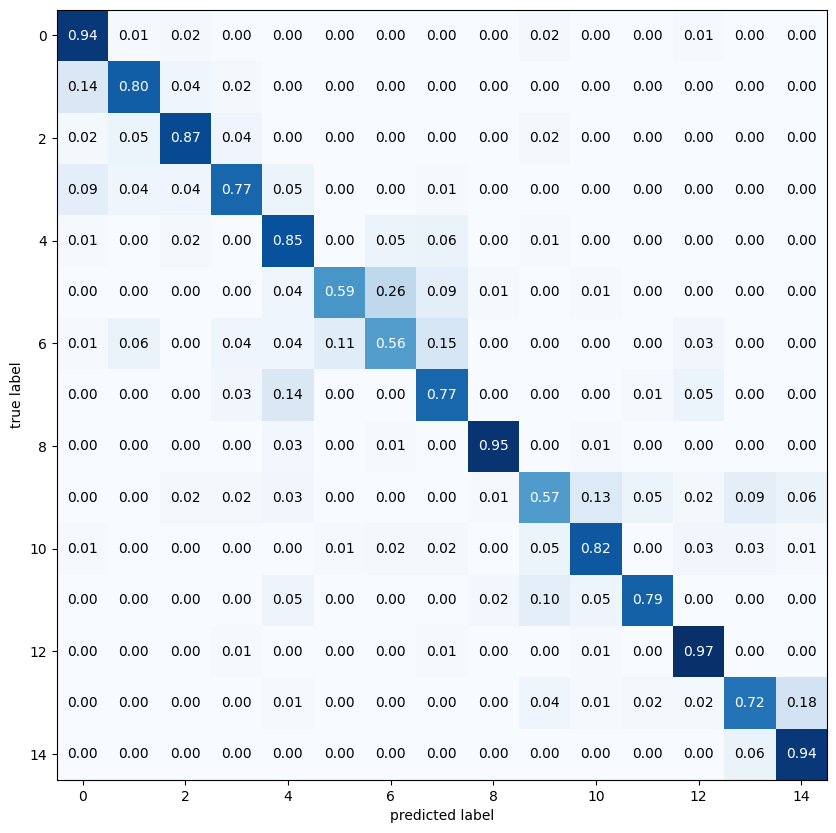

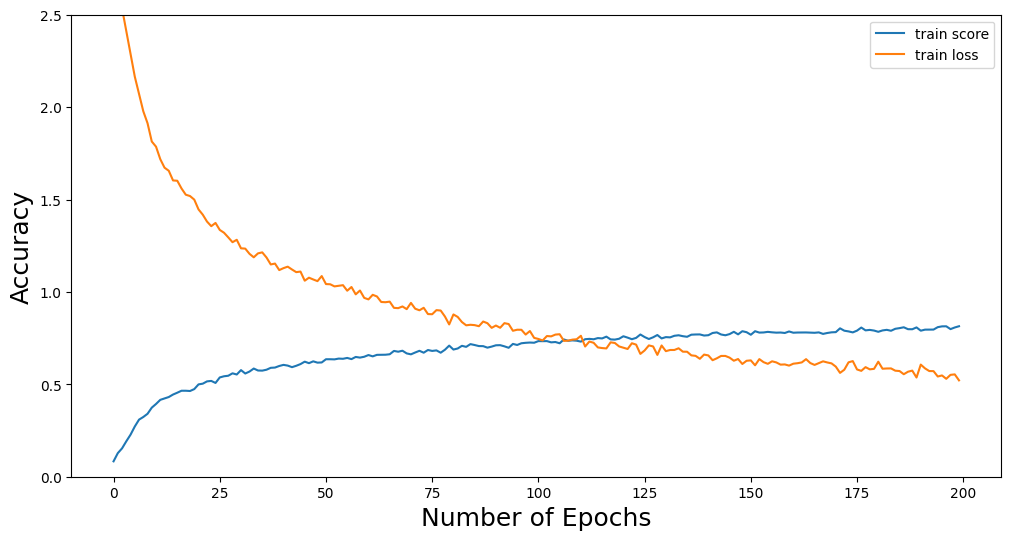

Train Data Shape: (1520, 300, 12)
Test Data Shape: (789, 300, 12)


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_273 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_39[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_39    │ (None, 31, 64)    │          0 │ conv1d_273[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_429         │ (None, 31, 64)    │          0 │ max_pooling1d_39… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_429[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_39        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ time2_vec_39[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_39[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_431         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_431[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_234 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_39[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_274 (Conv1D) │ (None, 31, 256)   │     16,896 │ add_234[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_432         │ (None, 31, 256)   │          0 │ conv1d_274[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_275 (Conv1D) │ (None, 31, 65)    │     16,705 │ dropout_432[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_275[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_235 (Add)       │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_234[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │     67,393 │ add_235[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_235[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_434         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_434[0][0

 Total params: 331,044 (1.26 MB)

 Trainable params: 330,916 (1.26 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 292ms/step - accuracy: 0.0827 - loss: 3.2040
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.1503 - loss: 2.7099
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.1962 - loss: 2.5454
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 317ms/step - accuracy: 0.2202 - loss: 2.4676
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 0.2564 - loss: 2.3622
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.3121 - loss: 2.1738
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.3508 - loss: 2.0449
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.3815 - loss: 1.9492
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step - accuracy: 0.4410 - loss: 1.7508
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.4423 - loss: 1.6876
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.4918 - loss: 1.5872
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9800 - loss: 0.0660
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8889 - loss: 0.5236
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
>#40: 
  train accuracy: 0.96447
  train loss    : 0.10759
  test accuracy: 0.86058
  test loss    : 0.64704

Accuracy: 0.86058 (+/-0.00000)
Loss: 0.64704 (+/-0.00000)


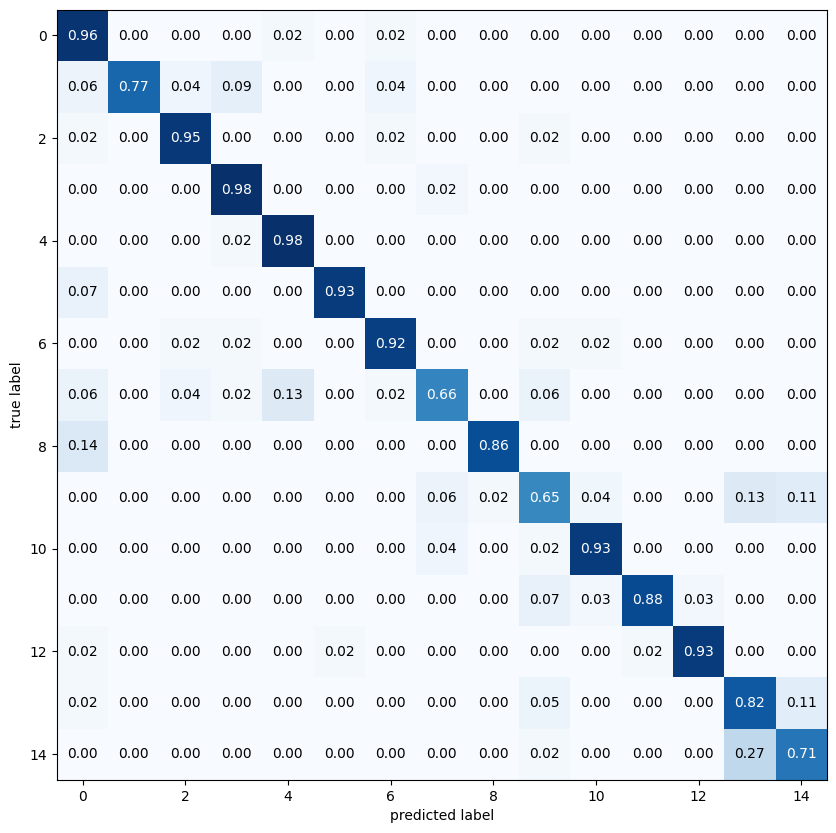

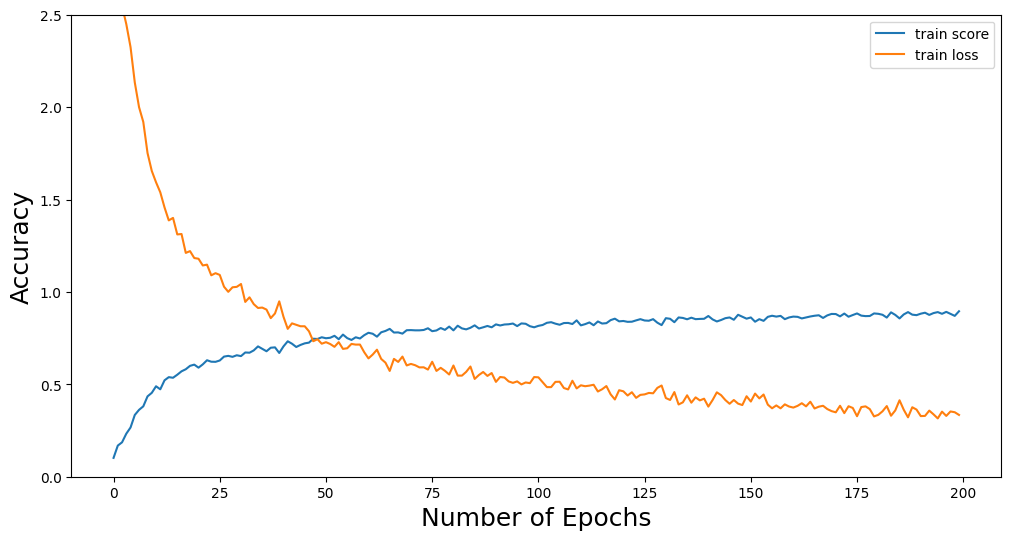

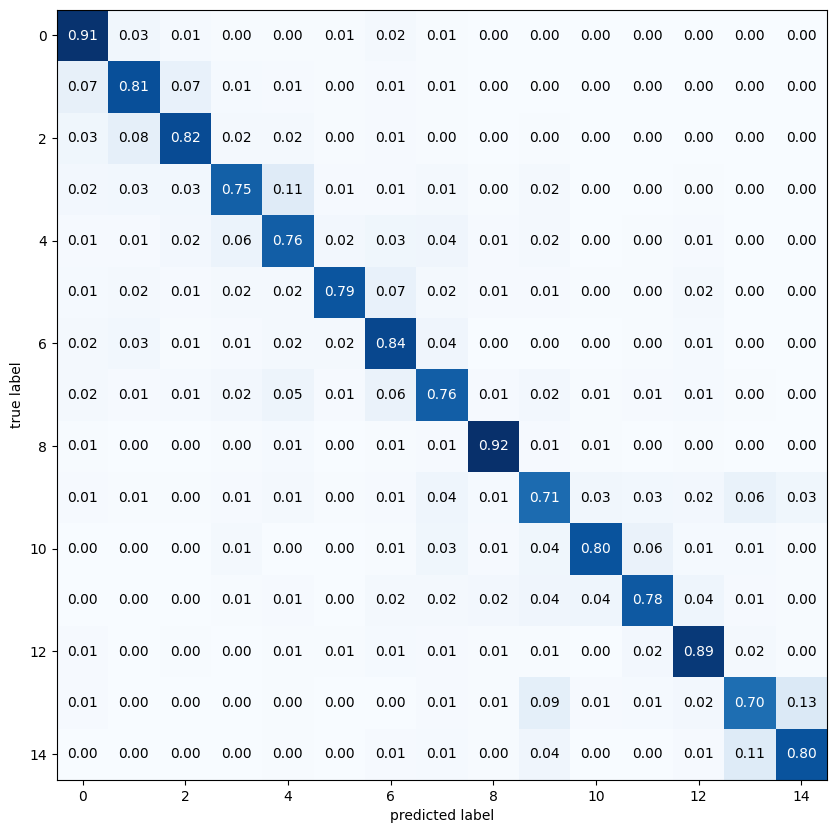

In [6]:

# Main
# ==============================================================================

globel_perd = []
globel_class = []

globel_perd1 = []
globel_class1 = []

# Create a workbook and add a worksheet.
workbook = xlsxwriter.Workbook(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\Trans_rslt.xlsx')
worksheet1 = workbook.add_worksheet('Subjects informations')

# Start from the first cell. Rows and columns are zero indexed.
row = 0

worksheet1.write(row, 0, 'Subject')
worksheet1.write(row, 1, 'Train_time')
worksheet1.write(row, 2, 'Test_time')
worksheet1.write(row, 3, 'Train_acc')
worksheet1.write(row, 4, 'Train_loss')
worksheet1.write(row, 5, 'Test_acc')
worksheet1.write(row, 6, 'Test_loss')
worksheet1.write(row, 7, 'MCC')

history = History()
for i in range(1, 41):
    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = run_my_experiment(i)

    globel_perd.append(y_pred)
    globel_class.append(testy)

    globel_perd1.extend(y_pred)
    globel_class1.extend(testy)

    mcc = matthews_corrcoef(testy, y_pred)
    mat = confusion_matrix(testy, y_pred)

    cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
    cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\S' + str(i) + 'trans_confusion_matrix.png')

    fig, axarr = plt.subplots(figsize=(12, 6), ncols=1)
    plot_renge = int(len(history.history['accuracy']) / i)
    global_renge = len(history.history['accuracy'])
    start_renge = global_renge - plot_renge
    axarr.plot(range(plot_renge), history.history['accuracy'][start_renge: global_renge], label='train score')
    axarr.plot(range(plot_renge), history.history['loss'][start_renge: global_renge], label='train loss')
    axarr.set_xlabel('Number of Epochs', fontsize=18)
    axarr.set_ylabel('Accuracy', fontsize=18)
    axarr.set_ylim([0, 2.5])
    plt.legend()
    plt.show()
    fig.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\S' + str(i) + 'trans_graphe.png')

    # Sheet informations
    worksheet1.write(i, 0, 'Sujet ' + str(i))
    worksheet1.write(i, 1, train_time)
    worksheet1.write(i, 2, test_time)
    worksheet1.write(i, 3, score_train)
    worksheet1.write(i, 4, loss_train)
    worksheet1.write(i, 5, score_test)
    worksheet1.write(i, 6, loss_test)
    worksheet1.write(i, 7, mcc)

workbook.close()

# Save prediction
new_data = {'pred_labels': globel_perd, 'class_labels': globel_class}
savemat(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\trans_global_predection.mat', new_data)

mat = confusion_matrix(globel_class1, globel_perd1)
cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\model_lr=0.001,bs=64\trans_global_confusion_matrix.png')


